In [2]:
import re

def parse_dms(coord):
    """
    Convert DMS (degrees, minutes, seconds) string to decimal degrees.
    Handles N/S/E/W.
    """
    # Extraire les nombres et les directions
    pattern = r'(\d+)°(\d+)?′?(\d+(?:\.\d+)?)?″?\s*([NSEW])'
    match = re.search(pattern, coord.strip())
    
    if not match:
        return None
    
    degrees = float(match.group(1))
    minutes = float(match.group(2)) if match.group(2) else 0
    seconds = float(match.group(3)) if match.group(3) else 0
    direction = match.group(4)
    
    dd = degrees + minutes / 60 + seconds / 3600
    
    if direction in ['S', 'W']:
        dd = -dd
        
    return dd

# Exemples de conversion
coords = ['14°13′30″ S', '13°20′ S', '12°35′ S', '22°53′ S', '48°09′ E', '49°57′ E']
for c in coords:
    print(f"{c} => {parse_dms(c)}")


14°13′30″ S => -14.225
13°20′ S => -13.333333333333334
12°35′ S => -12.583333333333334
22°53′ S => -22.883333333333333
48°09′ E => 48.15
49°57′ E => 49.95


C:\Users\adm1\AppData\Local\Temp\ipykernel_69684\1080874136.py:73: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


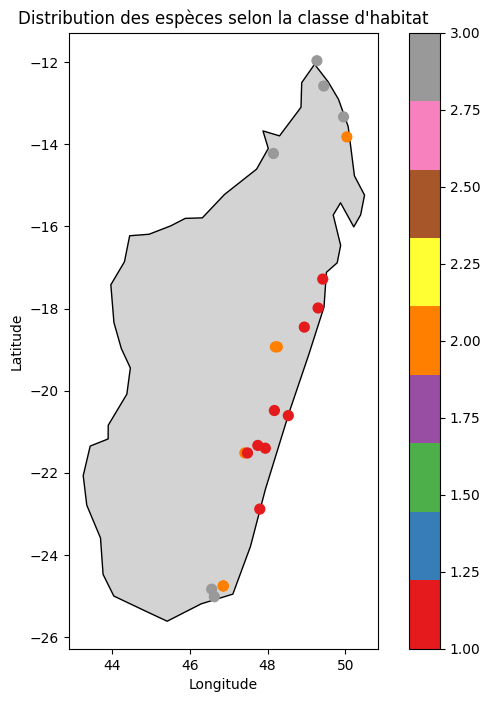

In [13]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import re

# Fonction pour convertir les coordonnées en degrés décimaux
def dms_to_dd(coord):
    parts = re.split('[°′″ ]+', coord.strip())
    parts = [p for p in parts if p != '']
    if len(parts) >= 2:
        degrees = float(parts[0])
        minutes = float(parts[1])
        seconds = float(parts[2]) if len(parts) > 2 else 0
        dd = degrees + minutes / 60 + seconds / 3600
        if 'S' in coord or 'W' in coord:
            dd = -dd
        return dd
    else:
        return None

data = {
    'Species': [
        'C. tetragona', 'C. dubardii', 'C. heimii', 'C. farafanganensis',
        'C. ambodirianaensis', 'C. dolichophylla', 'C. richardii', 'C. abbayesii',
        'C. millotii', 'C. leroyi', 'C. andrambovatensis', 'C. resinosa',
        'C. vianneyi', 'C. arenesiana', 'C. bertrandii', 'C. perrieri',
        'C. pervilleana', 'C. tsirananae', 'C. lancifolia', 'C. homollei',
        'C. kianjavatensis'
    ],
    'Latitude': [
        '14°13′30″ S', '13°20′ S', '12°35′ S', '22°53′ S',
        '18°27′08″ S', '20°29′ S', '17°17′ S', '24°45′15″ S',
        '21°31′ S', '21°20′ S', '21°24′3″ S', '20°36′26.6″ S',
        '18°56′ S', '18°56′ S', '25°01′ S', '24°50′ S',
        '13°49′17″ S', '11°58′ S', '21°31′ S', '17°59′13″ S',
        '24°45′15″ S'
    ],
    'Longitude': [
        '48°09′ E', '49°57′ E', '49°26′30″ E', '47°48′ E',
        '48°56′36″ E', '48°10′30″ E', '49°25′ E', '46°51′45″ E',
        '47°25′ E', '47°45′ E', '47°56′32″ E', '48°31′56.5″ E',
        '48°15′ E', '48°12′ E', '46°38′ E', '46°33′55″ E',
        '50°02′04″ E', '49°16′ E', '47°29′ E', '49°17′48″ E',
        '46°51′45″ E'
    ],
    'Habitat class': [
        3, 3, 3, 1,
        1, 1, 1, 2,
        2, 1, 1, 1,
        2, 2, 3, 3,
        2, 3, 1, 1,
        2
    ]
}


# Convertir en DataFrame
df = pd.DataFrame(data)

# Convertir les coordonnées
df['lat_dd'] = df['Latitude'].apply(parse_dms)
df['lon_dd'] = df['Longitude'].apply(parse_dms)

# Créer GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=[Point(xy) for xy in zip(df['lon_dd'], df['lat_dd'])],
    crs="EPSG:4326"
)

# Charger un fond de carte de Madagascar (exemple avec un fond mondial simplifié)
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
madagascar = world[world.name == 'Madagascar']

# Tracer
fig, ax = plt.subplots(figsize=(8, 8))
madagascar.plot(ax=ax, color='lightgrey', edgecolor='black')
gdf.plot(
    ax=ax,
    column='Habitat class',
    cmap='Set1',
    legend=True,
    markersize=50
)

plt.title('Distribution des espèces selon la classe d\'habitat')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


C:\Users\adm1\AppData\Local\Temp\ipykernel_69684\2999218276.py:33: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


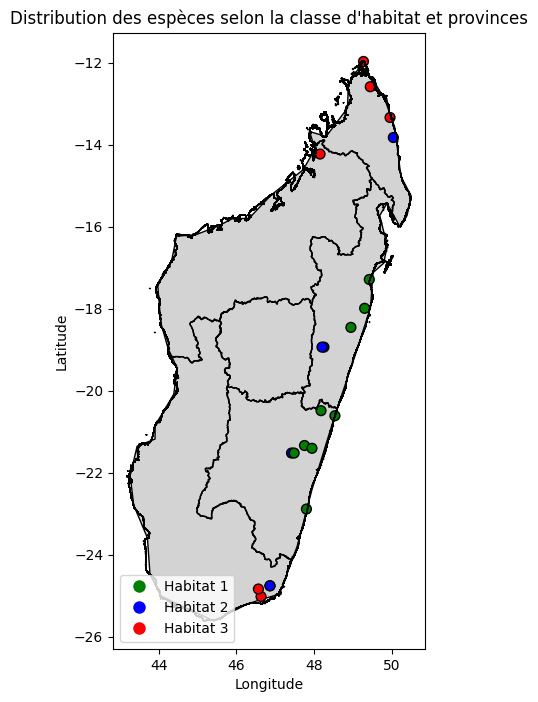

In [14]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import re

def parse_dms(coord):
    pattern = r'(\d+)°(\d+)?′?(\d+(?:\.\d+)?)?″?\s*([NSEW])'
    match = re.search(pattern, coord.strip())
    if not match:
        return None
    degrees = float(match.group(1))
    minutes = float(match.group(2)) if match.group(2) else 0
    seconds = float(match.group(3)) if match.group(3) else 0
    direction = match.group(4)
    dd = degrees + minutes / 60 + seconds / 3600
    if direction in ['S', 'W']:
        dd = -dd
    return dd

# Tes données (reprendre la liste complète que nous avons faite plus tôt)
# ...

# Conversion des coordonnées
df = pd.DataFrame(data)
df['lat_dd'] = df['Latitude'].apply(parse_dms)
df['lon_dd'] = df['Longitude'].apply(parse_dms)
df = df.dropna(subset=['lat_dd', 'lon_dd'])

gdf = gpd.GeoDataFrame(df, geometry=[Point(xy) for xy in zip(df['lon_dd'], df['lat_dd'])], crs="EPSG:4326")

# Charger Madagascar
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
madagascar = world[world.name == 'Madagascar']

# Charger limites des provinces (exemple: fichier shapefile ou geojson que tu as)
# Remplace par le chemin réel
provinces = gpd.read_file(r"./gadm41_MDG_1.shx")

# Tracer
fig, ax = plt.subplots(figsize=(8, 8))

madagascar.plot(ax=ax, color='lightgrey', edgecolor='black')
provinces.boundary.plot(ax=ax, color='black', linewidth=1)

# Colorer les points avec un mapping de couleur fixe
color_map = {1: 'green', 2: 'blue', 3: 'red'}
gdf.plot(
    ax=ax,
    color=gdf['Habitat class'].map(color_map),
    markersize=50,
    edgecolor='black'
)

# Légende manuelle
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Habitat 1', markerfacecolor='green', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Habitat 2', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Habitat 3', markerfacecolor='red', markersize=10),
]
ax.legend(handles=legend_elements, loc='lower left')

plt.title("Distribution des espèces selon la classe d'habitat et provinces")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


Empty DataFrame
Columns: [Species, Latitude, Longitude]
Index: []


C:\Users\adm1\AppData\Local\Temp\ipykernel_69684\946588502.py:40: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


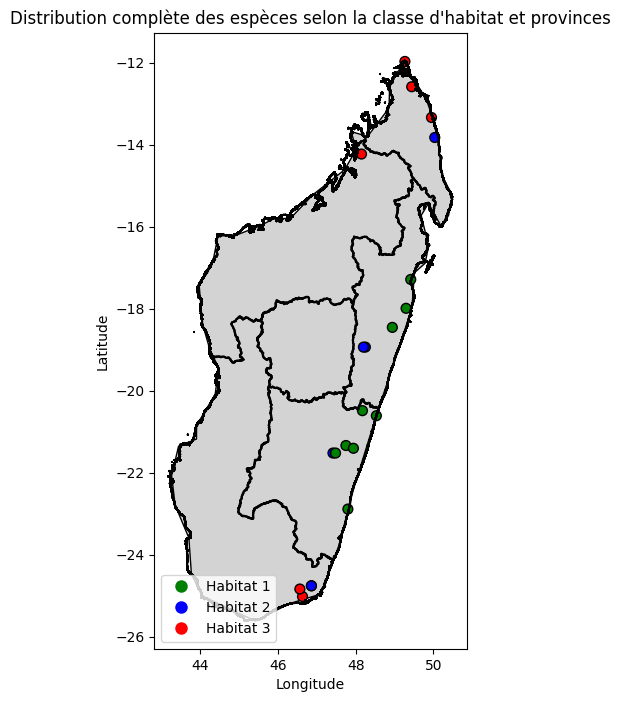

In [15]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import re

def parse_dms(coord):
    if pd.isnull(coord):
        return None
    pattern = r'(\d+)°\s*(\d+)?′?\s*(\d+(?:\.\d+)?)?″?\s*([NSEW])'
    match = re.search(pattern, coord.strip())
    if not match:
        print(f"⚠️ Coordonnée non reconnue : {coord}")
        return None
    degrees = float(match.group(1))
    minutes = float(match.group(2)) if match.group(2) else 0
    seconds = float(match.group(3)) if match.group(3) else 0
    direction = match.group(4)
    dd = degrees + minutes / 60 + seconds / 3600
    if direction in ['S', 'W']:
        dd = -dd
    return dd

# Ton DataFrame complet avec toutes les espèces et coordonnées
# Remplace ici par ta liste complète (je peux la générer si tu veux)

# Convertir les coordonnées
df['lat_dd'] = df['Latitude'].apply(parse_dms)
df['lon_dd'] = df['Longitude'].apply(parse_dms)

# Montrer les lignes où ça a échoué
print(df[df['lat_dd'].isnull() | df['lon_dd'].isnull()][['Species', 'Latitude', 'Longitude']])

# Créer le GeoDataFrame
gdf = gpd.GeoDataFrame(df.dropna(subset=['lat_dd', 'lon_dd']),
                        geometry=[Point(xy) for xy in zip(df['lon_dd'], df['lat_dd'])],
                        crs="EPSG:4326")

# Charger fond de carte et provinces
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
madagascar = world[world.name == 'Madagascar']
provinces = gpd.read_file("gadm41_MDG_1.shp")

# Tracer
fig, ax = plt.subplots(figsize=(8,8))
madagascar.plot(ax=ax, color='lightgrey', edgecolor='black')
provinces.boundary.plot(ax=ax, color='black')

color_map = {1: 'green', 2: 'blue', 3: 'red'}
gdf.plot(ax=ax, color=gdf['Habitat class'].map(color_map), markersize=50, edgecolor='black')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Habitat 1', markerfacecolor='green', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Habitat 2', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Habitat 3', markerfacecolor='red', markersize=10)
]
ax.legend(handles=legend_elements, loc='lower left')

plt.title("Distribution complète des espèces selon la classe d'habitat et provinces")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


KeyError: 'nb_mois_secs'

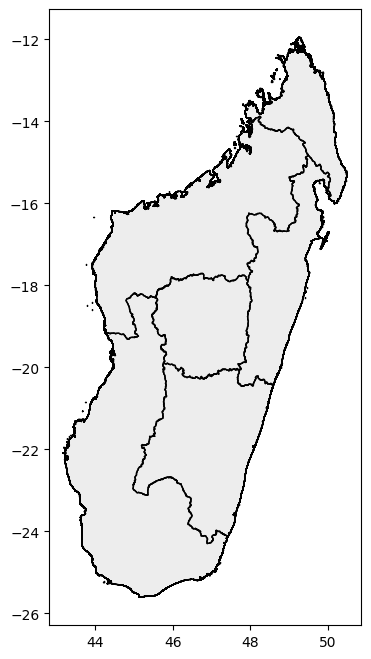

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt

# gdf = GeoDataFrame contenant les colonnes geometry et nb_mois_secs
fig, ax = plt.subplots(figsize=(8, 8))

# Fond de carte
provinces = gpd.read_file("gadm41_MDG_1.shp")
provinces.boundary.plot(ax=ax, color="black", linewidth=1)
provinces.plot(ax=ax, color="lightgrey", alpha=0.4)

# Affichage des points avec nb_mois_secs
gdf.plot(
    ax=ax,
    column='nb_mois_secs',
    cmap='OrRd',  # ou autre colormap
    legend=True,
    markersize=50
)

plt.title("Nombre de mois de sécheresse (selon Gaussen)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


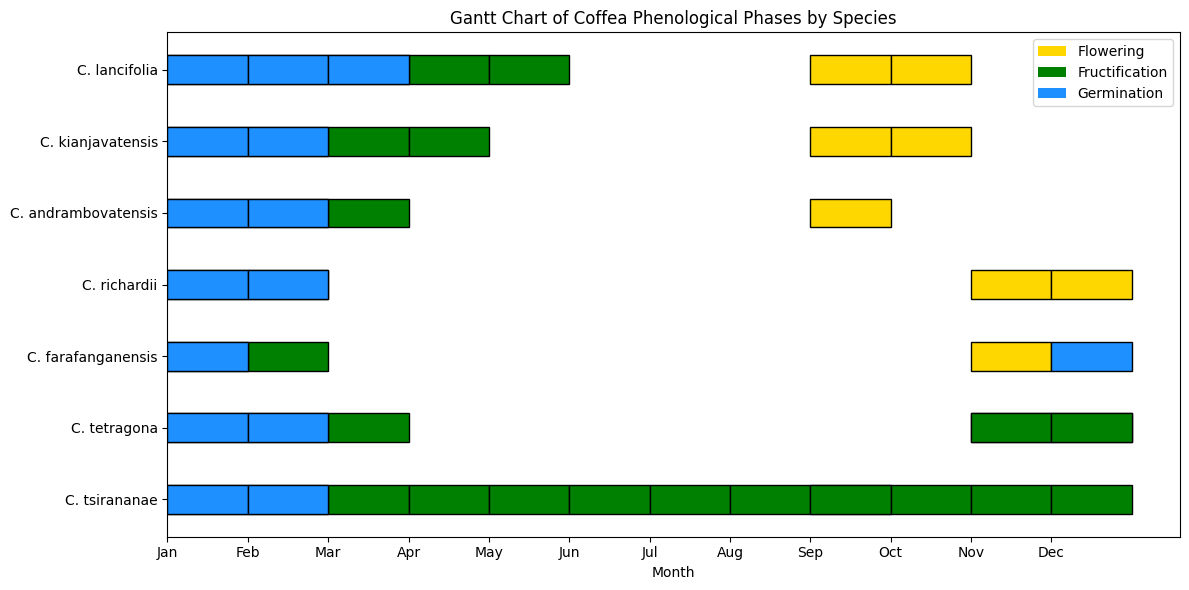

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# Define the month labels
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Define phenological phases per species (simplified for visualization)
phenology = {
    "C. lancifolia": {
        "series": "Verae",
        "flowering": [8, 9],  # Sept-Oct
        "fructification": [0, 1, 2, 3, 4],  # Jan-May
        "germination": [0, 1, 2]  # Jan-Mar
    },
    "C. kianjavatensis": {
        "series": "Verae",
        "flowering": [8, 9],
        "fructification": [0, 1, 2, 3],
        "germination": [0, 1]
    },
    "C. andrambovatensis": {
        "series": "Multiflorae",
        "flowering": [8],
        "fructification": [0, 1, 2],
        "germination": [0, 1]
    },
    "C. richardii": {
        "series": "Millotii complex",
        "flowering": [10, 11],  # Nov-Dec
        "fructification": [0, 1],  # Jan-Feb
        "germination": [0, 1]  # same year
    },
    "C. farafanganensis": {
        "series": "Millotii complex",
        "flowering": [10],
        "fructification": [0, 1],
        "germination": [11, 0]  # Dec-Jan
    },
    "C. tetragona": {
        "series": "Garcinioides",
        "flowering": [10, 11],
        "fructification": [0, 1, 2, 10, 11],  # Jan-Mar or Nov-Dec
        "germination": [0, 1]
    },
    "C. tsirananae": {
        "series": "Subterminales",
        "flowering": [8],
        "fructification": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],  # 12 months
        "germination": [0, 1]
    }
}

# Create a plot
fig, ax = plt.subplots(figsize=(12, 6))
y_labels = []
colors = {'flowering': 'gold', 'fructification': 'green', 'germination': 'dodgerblue'}
legend_elements = [Patch(facecolor=val, label=key.capitalize()) for key, val in colors.items()]

for i, (species, data) in enumerate(phenology.items()):
    y_labels.append(species)
    for phase, color in colors.items():
        for month in data[phase]:
            ax.barh(i, 1, left=month, height=0.4, color=color, edgecolor='black')

# Format plot
ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels(y_labels)
ax.set_xticks(range(12))
ax.set_xticklabels(months)
ax.invert_yaxis()
ax.set_xlabel("Month")
ax.set_title("Gantt Chart of Coffea Phenological Phases by Species")
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()


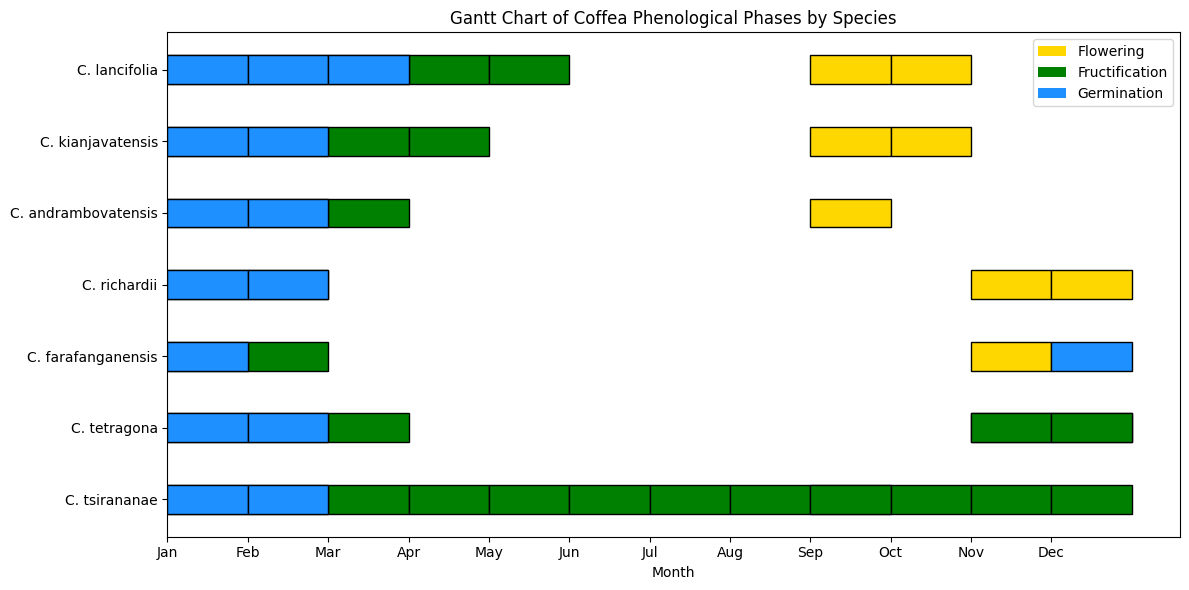

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Redefine phenology data after kernel reset
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

phenology = {
    "C. lancifolia": {
        "series": "Verae",
        "flowering": [8, 9],  # Sept-Oct
        "fructification": [0, 1, 2, 3, 4],  # Jan-May
        "germination": [0, 1, 2]  # Jan-Mar
    },
    "C. kianjavatensis": {
        "series": "Verae",
        "flowering": [8, 9],
        "fructification": [0, 1, 2, 3],
        "germination": [0, 1]
    },
    "C. andrambovatensis": {
        "series": "Multiflorae",
        "flowering": [8],
        "fructification": [0, 1, 2],
        "germination": [0, 1]
    },
    "C. richardii": {
        "series": "Millotii complex",
        "flowering": [10, 11],  # Nov-Dec
        "fructification": [0, 1],  # Jan-Feb
        "germination": [0, 1]  # same year
    },
    "C. farafanganensis": {
        "series": "Millotii complex",
        "flowering": [10],
        "fructification": [0, 1],
        "germination": [11, 0]  # Dec-Jan
    },
    "C. tetragona": {
        "series": "Garcinioides",
        "flowering": [10, 11],
        "fructification": [0, 1, 2, 10, 11],  # Jan-Mar or Nov-Dec
        "germination": [0, 1]
    },
    "C. tsirananae": {
        "series": "Subterminales",
        "flowering": [8],
        "fructification": list(range(12)),  # 12 months
        "germination": [0, 1]
    }
}

# Plot setup
fig, ax = plt.subplots(figsize=(12, 6))
y_labels = []
colors = {'flowering': 'gold', 'fructification': 'green', 'germination': 'dodgerblue'}
legend_elements = [Patch(facecolor=val, label=key.capitalize()) for key, val in colors.items()]

# Plot bars
for i, (species, data) in enumerate(phenology.items()):
    y_labels.append(species)
    for phase, color in colors.items():
        for month in data[phase]:
            ax.barh(i, 1, left=month, height=0.4, color=color, edgecolor='black')

# Final plot formatting
ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels(y_labels)
ax.set_xticks(range(12))
ax.set_xticklabels(months)
ax.invert_yaxis()
ax.set_xlabel("Month")
ax.set_title("Gantt Chart of Coffea Phenological Phases by Species")
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()


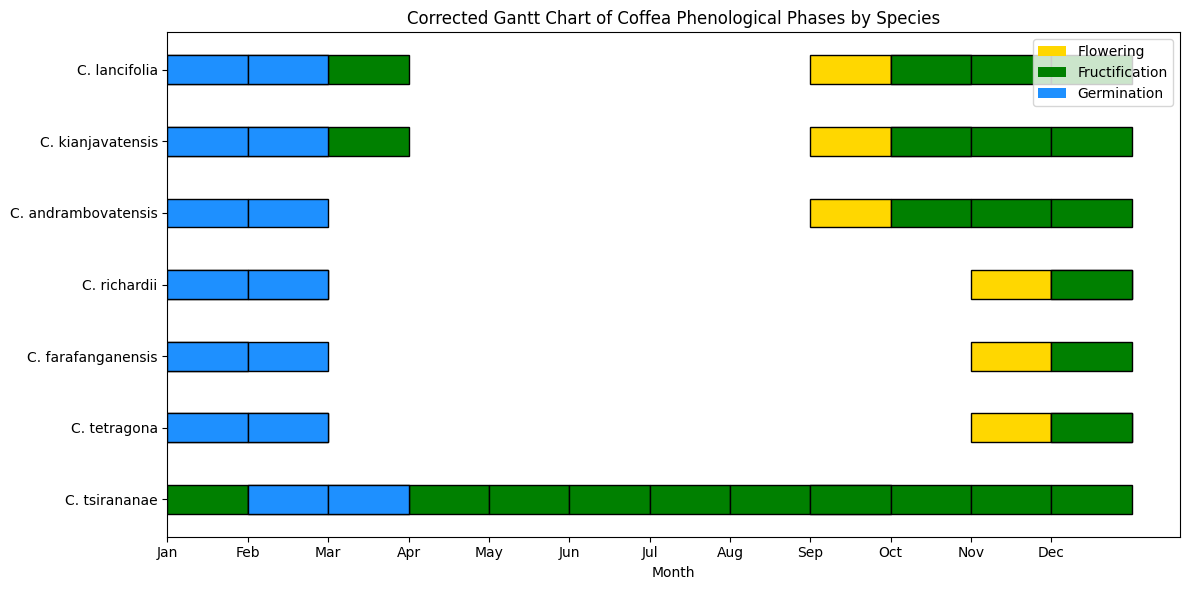

In [3]:
# Adjust the phenology based on corrected flowering → fructification → germination sequence
# We'll assume that fruiting starts the month after flowering and lasts based on known series traits.

adjusted_phenology = {}

# Define approximate fruit durations by series (from previous analysis)
fruit_duration_by_series = {
    "Verae": 5,             # 5 months
    "Multiflorae": 3,       # 3 months
    "Millotii complex": 2,  # 2 months (or extended)
    "Garcinioides": 2,      # 2 months (but may have dual peaks)
    "Subterminales": 12     # 12 months
}

# Define germination timing offsets (0 = same year, 1 = next rainy season)
germination_delay_by_series = {
    "Verae": 0,
    "Multiflorae": 0,
    "Millotii complex": 0,
    "Garcinioides": 0,
    "Subterminales": 1
}

# Adjust phenology
for species, data in phenology.items():
    series = data["series"]
    flowering_months = data["flowering"]
    fruit_months = []
    for start in flowering_months:
        duration = fruit_duration_by_series.get(series, 2)
        fruit_months.extend([(start + 1 + i) % 12 for i in range(duration)])
    fruit_months = sorted(set(fruit_months))

    # Germination 1–2 months after fruiting ends (same or next rainy season)
    last_fruit_month = max(fruit_months)
    germ_start = (last_fruit_month + 1) % 12 if germination_delay_by_series[series] == 0 else (last_fruit_month + 2) % 12
    germ_months = [germ_start, (germ_start + 1) % 12]

    adjusted_phenology[species] = {
        "flowering": flowering_months,
        "fructification": fruit_months,
        "germination": germ_months
    }

# Plot the corrected Gantt chart
fig, ax = plt.subplots(figsize=(12, 6))
colors = {'flowering': 'gold', 'fructification': 'green', 'germination': 'dodgerblue'}
legend_elements = [Patch(facecolor=val, label=key.capitalize()) for key, val in colors.items()]

for i, (species, data) in enumerate(adjusted_phenology.items()):
    for phase, color in colors.items():
        for month in data[phase]:
            ax.barh(i, 1, left=month, height=0.4, color=color, edgecolor='black')

ax.set_yticks(range(len(adjusted_phenology)))
ax.set_yticklabels(adjusted_phenology.keys())
ax.set_xticks(range(12))
ax.set_xticklabels(months)
ax.invert_yaxis()
ax.set_xlabel("Month")
ax.set_title("Corrected Gantt Chart of Coffea Phenological Phases by Species")
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()


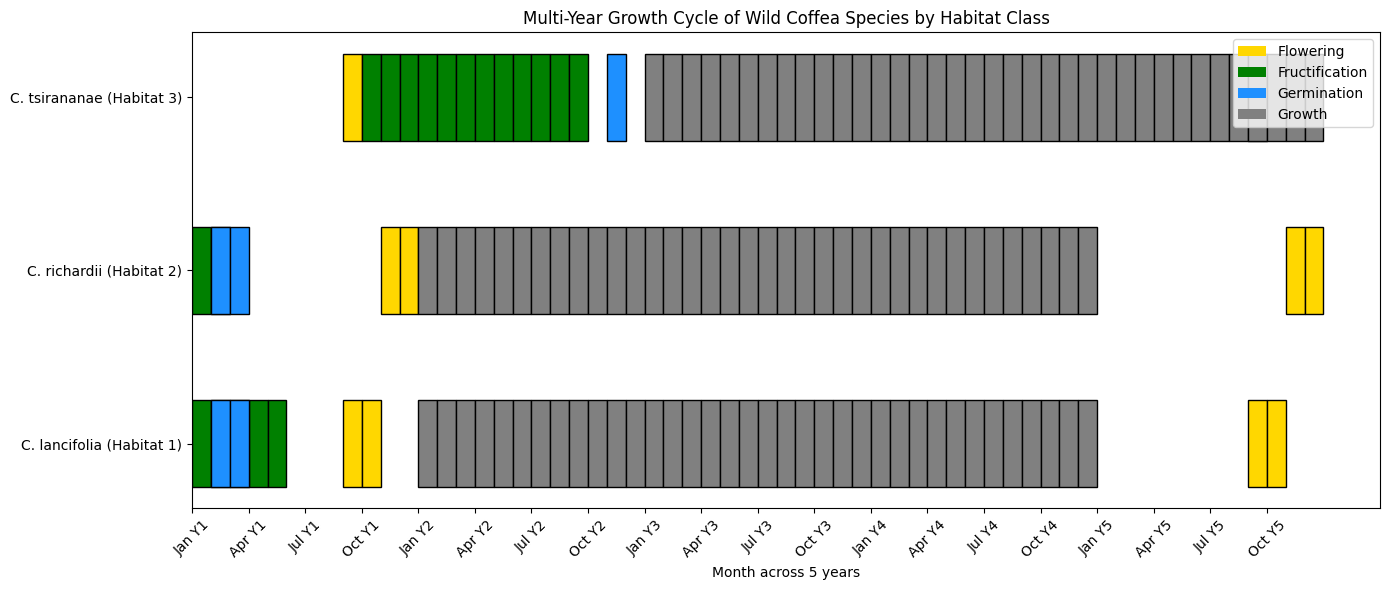

In [4]:
# Define representative species per habitat class for multi-year Gantt chart
# Based on paper data:
# - Habitat 1: C. lancifolia (Verae) - humid
# - Habitat 2: C. richardii (Millotii complex) - intermediate
# - Habitat 3: C. tsirananae (Subterminales) - dry

# Year labels for a 5-year period
years = [f'Y{i}' for i in range(1, 6)]
months_full = months * 5  # Repeat months for 5 years

# Construct multi-year phenology per selected species
multi_year_phenology = {
    "C. lancifolia (Habitat 1)": {
        "Year 1": {
            "flowering": [8 + 12 * 0, 9 + 12 * 0],  # Sept-Oct Y1
            "fructification": [i + 12 * 0 for i in range(0, 5)],  # Jan–May Y1
            "germination": [i + 12 * 0 for i in range(1, 3)],  # Feb–Mar Y1
        },
        "Year 2–4": {
            "growth": list(range(12, 48))  # Full years 2 to 4
        },
        "Year 5": {
            "flowering": [8 + 12 * 4, 9 + 12 * 4],  # Sept-Oct Y5
        }
    },
    "C. richardii (Habitat 2)": {
        "Year 1": {
            "flowering": [10, 11],  # Nov-Dec Y1
            "fructification": [0, 1],  # Jan-Feb Y1
            "germination": [1, 2]  # Feb-Mar Y1
        },
        "Year 2–4": {
            "growth": list(range(12, 48))
        },
        "Year 5": {
            "flowering": [10 + 48, 11 + 48],  # Nov-Dec Y5
        }
    },
    "C. tsirananae (Habitat 3)": {
        "Year 1": {
            "flowering": [8],  # Sept Y1
            "fructification": list(range(9, 21)),  # Oct Y1 to Sept Y2 (12 months)
            "germination": [10 + 12]  # Nov Y2
        },
        "Year 2–4": {
            "growth": list(range(24, 60))
        },
        "Year 5": {
            "flowering": [8 + 48]  # Sept Y5
        }
    }
}

# Plot multi-year Gantt chart
fig, ax = plt.subplots(figsize=(14, 6))
colors_ext = {'flowering': 'gold', 'fructification': 'green', 'germination': 'dodgerblue', 'growth': 'gray'}
legend_elements_ext = [Patch(facecolor=val, label=key.capitalize()) for key, val in colors_ext.items()]

# Plot bars
for i, (species, phases) in enumerate(multi_year_phenology.items()):
    for phase_label, color in colors_ext.items():
        for key, months_list in phases.items():
            if phase_label in months_list:
                for m in months_list[phase_label]:
                    ax.barh(i, 1, left=m, height=0.5, color=color, edgecolor='black')

# Set up axes
ax.set_yticks(range(len(multi_year_phenology)))
ax.set_yticklabels(multi_year_phenology.keys())
ax.set_xticks([i for i in range(0, 60, 3)])
ax.set_xticklabels([months[i % 12] + f' Y{(i // 12) + 1}' for i in range(0, 60, 3)], rotation=45)
ax.set_xlabel("Month across 5 years")
ax.set_title("Multi-Year Growth Cycle of Wild Coffea Species by Habitat Class")
ax.legend(handles=legend_elements_ext, loc='upper right')

plt.tight_layout()
plt.show()


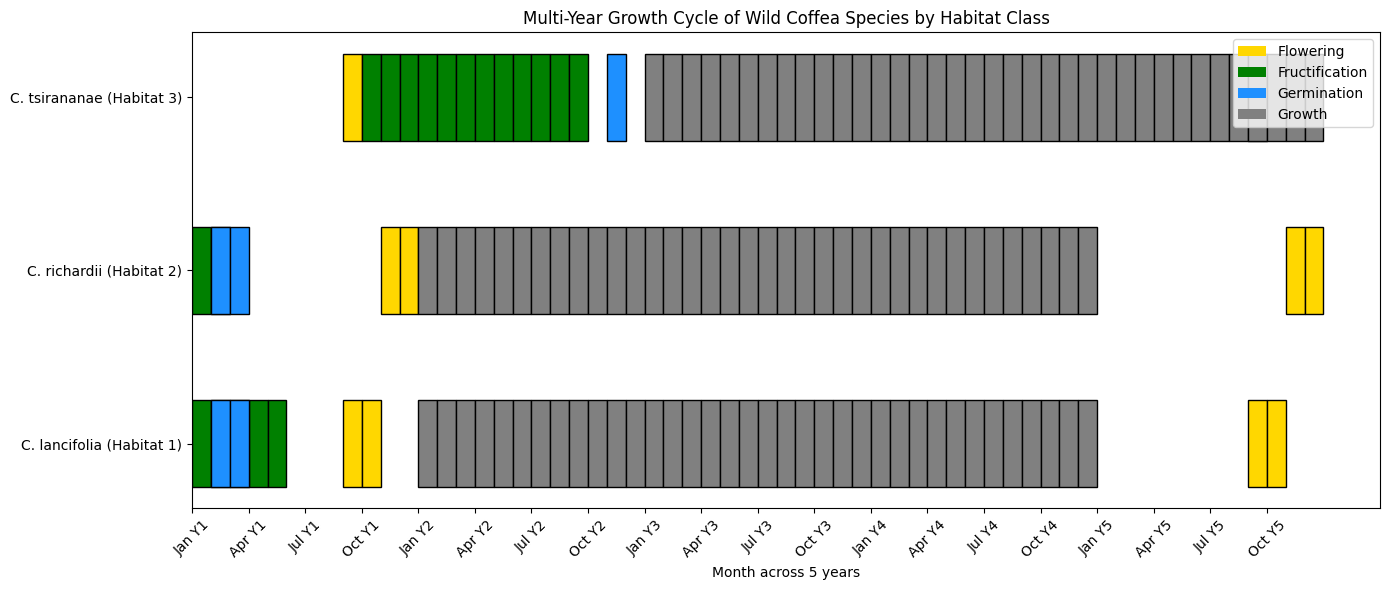

In [5]:
# Define representative species per habitat class for multi-year Gantt chart
# Based on paper data:
# - Habitat 1: C. lancifolia (Verae) - humid
# - Habitat 2: C. richardii (Millotii complex) - intermediate
# - Habitat 3: C. tsirananae (Subterminales) - dry

# Year labels for a 5-year period
years = [f'Y{i}' for i in range(1, 6)]
months_full = months * 5  # Repeat months for 5 years

# Construct multi-year phenology per selected species
multi_year_phenology = {
    "C. lancifolia (Habitat 1)": {
        "Year 1": {
            "flowering": [8 + 12 * 0, 9 + 12 * 0],  # Sept-Oct Y1
            "fructification": [i + 12 * 0 for i in range(0, 5)],  # Jan–May Y1
            "germination": [i + 12 * 0 for i in range(1, 3)],  # Feb–Mar Y1
        },
        "Year 2–4": {
            "growth": list(range(12, 48))  # Full years 2 to 4
        },
        "Year 5": {
            "flowering": [8 + 12 * 4, 9 + 12 * 4],  # Sept-Oct Y5
        }
    },
    "C. richardii (Habitat 2)": {
        "Year 1": {
            "flowering": [10, 11],  # Nov-Dec Y1
            "fructification": [0, 1],  # Jan-Feb Y1
            "germination": [1, 2]  # Feb-Mar Y1
        },
        "Year 2–4": {
            "growth": list(range(12, 48))
        },
        "Year 5": {
            "flowering": [10 + 48, 11 + 48],  # Nov-Dec Y5
        }
    },
    "C. tsirananae (Habitat 3)": {
        "Year 1": {
            "flowering": [8],  # Sept Y1
            "fructification": list(range(9, 21)),  # Oct Y1 to Sept Y2 (12 months)
            "germination": [10 + 12]  # Nov Y2
        },
        "Year 2–4": {
            "growth": list(range(24, 60))
        },
        "Year 5": {
            "flowering": [8 + 48]  # Sept Y5
        }
    }
}

# Plot multi-year Gantt chart
fig, ax = plt.subplots(figsize=(14, 6))
colors_ext = {'flowering': 'gold', 'fructification': 'green', 'germination': 'dodgerblue', 'growth': 'gray'}
legend_elements_ext = [Patch(facecolor=val, label=key.capitalize()) for key, val in colors_ext.items()]

# Plot bars
for i, (species, phases) in enumerate(multi_year_phenology.items()):
    for phase_label, color in colors_ext.items():
        for key, months_list in phases.items():
            if phase_label in months_list:
                for m in months_list[phase_label]:
                    ax.barh(i, 1, left=m, height=0.5, color=color, edgecolor='black')

# Set up axes
ax.set_yticks(range(len(multi_year_phenology)))
ax.set_yticklabels(multi_year_phenology.keys())
ax.set_xticks([i for i in range(0, 60, 3)])
ax.set_xticklabels([months[i % 12] + f' Y{(i // 12) + 1}' for i in range(0, 60, 3)], rotation=45)
ax.set_xlabel("Month across 5 years")
ax.set_title("Multi-Year Growth Cycle of Wild Coffea Species by Habitat Class")
ax.legend(handles=legend_elements_ext, loc='upper right')

plt.tight_layout()
plt.show()


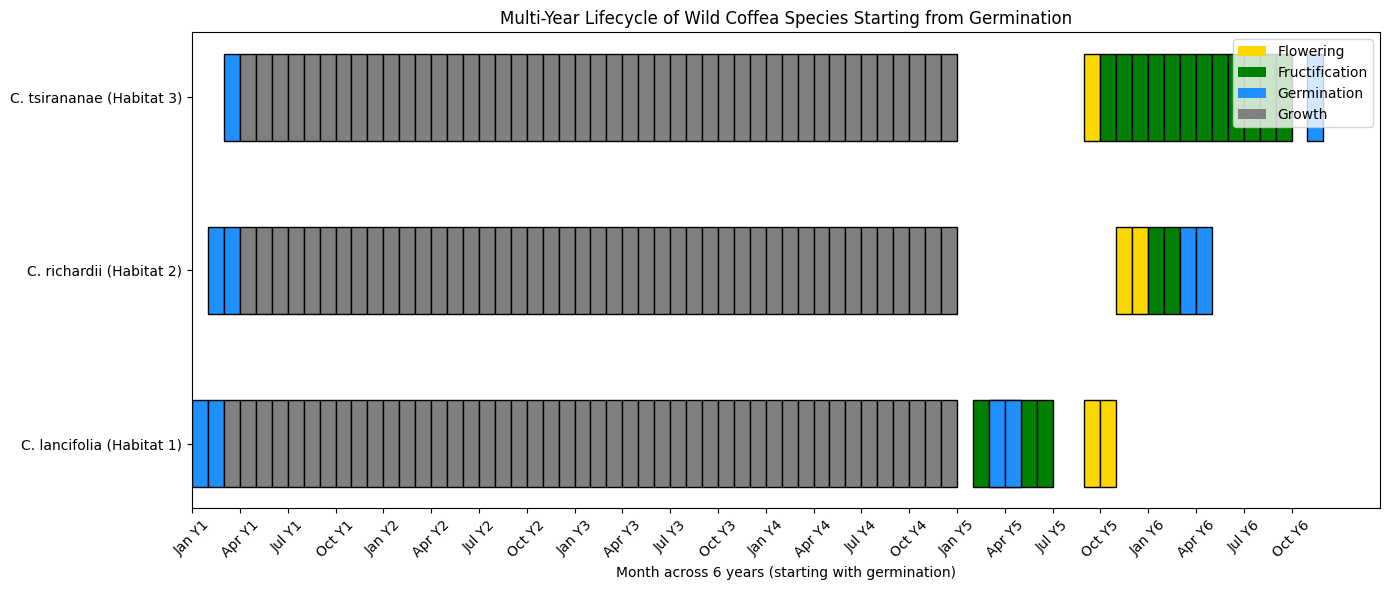

In [7]:
# Update the multi-year phenology chart to start with a germination event (instead of flowering in Year 1)
# This germination will be followed by vegetative growth, and first flowering in Year 5

multi_year_phenology_germstart = {
    "C. lancifolia (Habitat 1)": {
        "Year 1": {
            "germination": [0, 1],  # Jan-Feb Y1
        },
        "Year 1–4": {
            "growth": list(range(2, 48))  # From March Y1 to Dec Y4
        },
        "Year 5": {
            "flowering": [8 + 48, 9 + 48],  # Sept-Oct Y5
            "fructification": [i + 49 for i in range(0, 5)],  # Jan–May Y5
            "germination": [50, 51]  # Feb-Mar Y5
        }
    },
    "C. richardii (Habitat 2)": {
        "Year 1": {
            "germination": [1, 2],  # Feb-Mar Y1
        },
        "Year 1–4": {
            "growth": list(range(3, 48))
        },
        "Year 5": {
            "flowering": [10 + 48, 11 + 48],  # Nov-Dec Y5
            "fructification": [0 + 60, 1 + 60],  # Jan-Feb Y6
            "germination": [2 + 60, 3 + 60]  # Mar-Apr Y6
        }
    },
    "C. tsirananae (Habitat 3)": {
        "Year 1": {
            "germination": [2]  # March Y1
        },
        "Year 1–4": {
            "growth": list(range(3, 48))
        },
        "Year 5": {
            "flowering": [8 + 48],  # Sept Y5
            "fructification": list(range(9 + 48, 9 + 48 + 12)),  # Oct Y5 to Sept Y6
            "germination": [10 + 60]  # Nov Y6
        }
    }
}

# Plot adjusted Gantt chart starting from germination
fig, ax = plt.subplots(figsize=(14, 6))
colors_ext = {'flowering': 'gold', 'fructification': 'green', 'germination': 'dodgerblue', 'growth': 'gray'}
legend_elements_ext = [Patch(facecolor=val, label=key.capitalize()) for key, val in colors_ext.items()]

for i, (species, phases) in enumerate(multi_year_phenology_germstart.items()):
    for phase_label, color in colors_ext.items():
        for key, months_list in phases.items():
            if phase_label in months_list:
                for m in months_list[phase_label]:
                    ax.barh(i, 1, left=m, height=0.5, color=color, edgecolor='black')

# Configure axes
ax.set_yticks(range(len(multi_year_phenology_germstart)))
ax.set_yticklabels(multi_year_phenology_germstart.keys())
ax.set_xticks([i for i in range(0, 72, 3)])
ax.set_xticklabels([months[i % 12] + f' Y{(i // 12) + 1}' for i in range(0, 72, 3)], rotation=45)
ax.set_xlabel("Month across 6 years (starting with germination)")
ax.set_title("Multi-Year Lifecycle of Wild Coffea Species Starting from Germination")
ax.legend(handles=legend_elements_ext, loc='upper right')

plt.tight_layout()
plt.show()


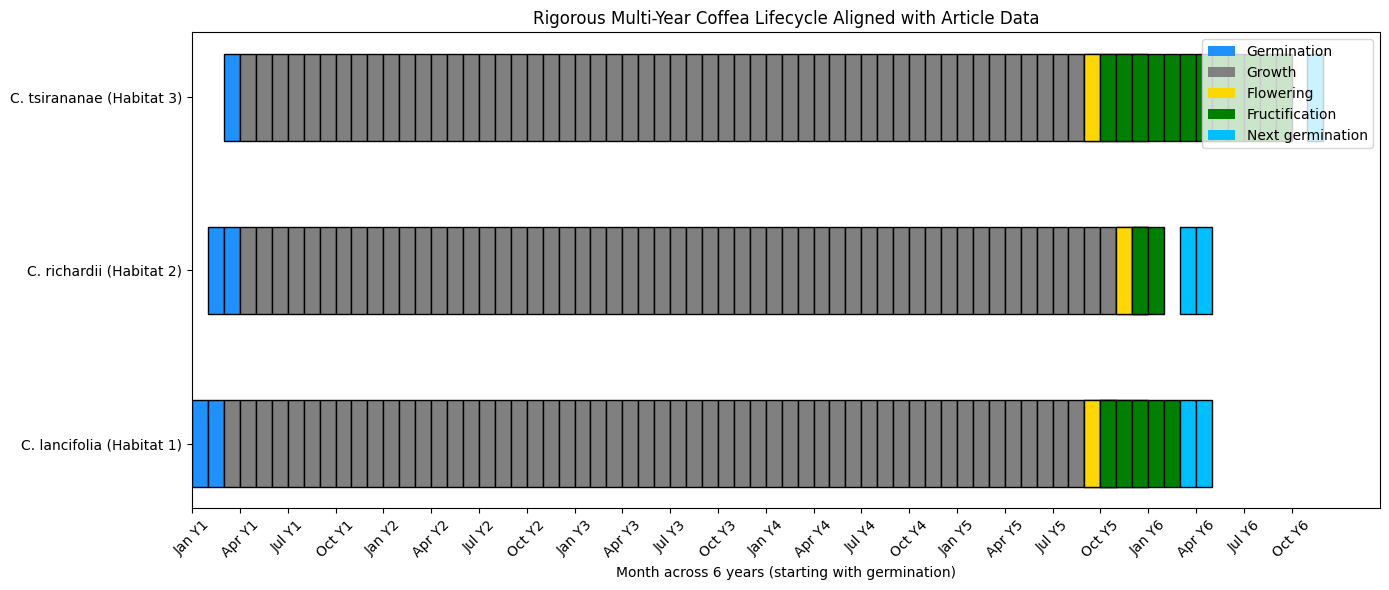

In [8]:
# Reconstruct corrected, article-aligned phenological cycles for 3 species
# All timing is relative to first germination in Year 1

# Define flowering months (absolute month indices across years)
# Fruiting begins AFTER flowering, germination occurs AFTER fruiting
fixed_phenology = {
    "C. lancifolia (Habitat 1)": {
        "germination": [0, 1],  # Jan–Feb Y1
        "growth": list(range(2, 60)),  # Mar Y1 to Dec Y5
        "flowering": [8 + 48, 9 + 48],  # Sept–Oct Y5 (months 56–57)
        "fructification": [i + 1 for i in range(8 + 48, 8 + 48 + 5)],  # Oct Y5 to Feb Y6
        "next_germination": [2 + 60, 3 + 60]  # Mar–Apr Y6
    },
    "C. richardii (Habitat 2)": {
        "germination": [1, 2],  # Feb–Mar Y1
        "growth": list(range(3, 60)),  # Apr Y1 to Dec Y5
        "flowering": [10 + 48, 11 + 48],  # Nov–Dec Y5 (months 58–59)
        "fructification": [i + 1 for i in range(10 + 48, 10 + 48 + 2)],  # Dec Y5 to Jan Y6
        "next_germination": [2 + 60, 3 + 60]  # Mar–Apr Y6
    },
    "C. tsirananae (Habitat 3)": {
        "germination": [2],  # Mar Y1
        "growth": list(range(3, 60)),  # Apr Y1 to Dec Y5
        "flowering": [8 + 48],  # Sept Y5 (month 56)
        "fructification": list(range(9 + 48, 9 + 48 + 12)),  # Oct Y5 to Sept Y6 (months 57–68)
        "next_germination": [10 + 60]  # Nov Y6 (month 70)
    }
}

# Plot strictly corrected Gantt chart
fig, ax = plt.subplots(figsize=(14, 6))
colors_final = {
    'germination': 'dodgerblue',
    'growth': 'gray',
    'flowering': 'gold',
    'fructification': 'green',
    'next_germination': 'deepskyblue'
}
legend_elements_final = [Patch(facecolor=val, label=key.replace("_", " ").capitalize()) for key, val in colors_final.items()]

for i, (species, phases) in enumerate(fixed_phenology.items()):
    for phase_label, color in colors_final.items():
        for m in phases[phase_label]:
            ax.barh(i, 1, left=m, height=0.5, color=color, edgecolor='black')

# Setup timeline and labels
ax.set_yticks(range(len(fixed_phenology)))
ax.set_yticklabels(fixed_phenology.keys())
ax.set_xticks([i for i in range(0, 72, 3)])
ax.set_xticklabels([months[i % 12] + f' Y{(i // 12) + 1}' for i in range(0, 72, 3)], rotation=45)
ax.set_xlabel("Month across 6 years (starting with germination)")
ax.set_title("Rigorous Multi-Year Coffea Lifecycle Aligned with Article Data")
ax.legend(handles=legend_elements_final, loc='upper right')

plt.tight_layout()
plt.show()


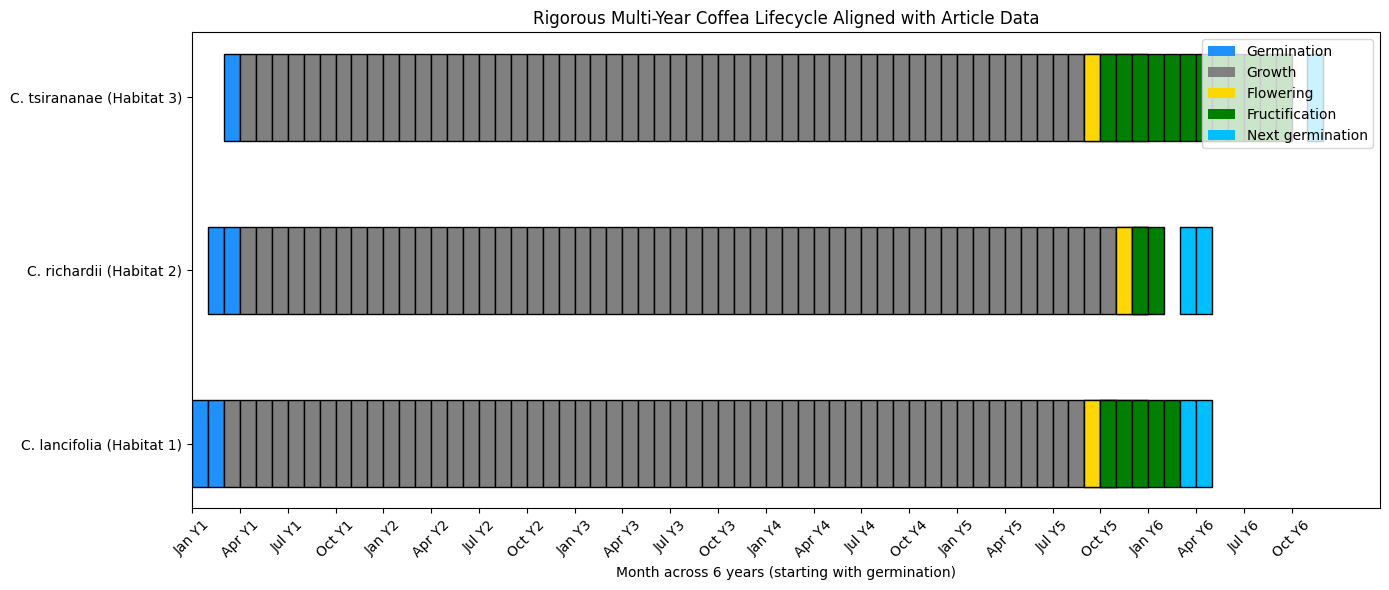

In [9]:
# Re-initialize after code execution reset

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Month labels
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Define corrected phenology data for 3 species starting from first germination
fixed_phenology = {
    "C. lancifolia (Habitat 1)": {
        "germination": [0, 1],  # Jan–Feb Y1
        "growth": list(range(2, 60)),  # Mar Y1 to Dec Y5
        "flowering": [8 + 48, 9 + 48],  # Sept–Oct Y5 (months 56–57)
        "fructification": [i + 1 for i in range(8 + 48, 8 + 48 + 5)],  # Oct Y5 to Feb Y6
        "next_germination": [2 + 60, 3 + 60]  # Mar–Apr Y6
    },
    "C. richardii (Habitat 2)": {
        "germination": [1, 2],  # Feb–Mar Y1
        "growth": list(range(3, 60)),  # Apr Y1 to Dec Y5
        "flowering": [10 + 48, 11 + 48],  # Nov–Dec Y5 (months 58–59)
        "fructification": [i + 1 for i in range(10 + 48, 10 + 48 + 2)],  # Dec Y5 to Jan Y6
        "next_germination": [2 + 60, 3 + 60]  # Mar–Apr Y6
    },
    "C. tsirananae (Habitat 3)": {
        "germination": [2],  # Mar Y1
        "growth": list(range(3, 60)),  # Apr Y1 to Dec Y5
        "flowering": [8 + 48],  # Sept Y5 (month 56)
        "fructification": list(range(9 + 48, 9 + 48 + 12)),  # Oct Y5 to Sept Y6 (months 57–68)
        "next_germination": [10 + 60]  # Nov Y6 (month 70)
    }
}

# Plot Gantt chart
fig, ax = plt.subplots(figsize=(14, 6))
colors_final = {
    'germination': 'dodgerblue',
    'growth': 'gray',
    'flowering': 'gold',
    'fructification': 'green',
    'next_germination': 'deepskyblue'
}
legend_elements_final = [Patch(facecolor=val, label=key.replace("_", " ").capitalize()) for key, val in colors_final.items()]

# Plot bars
for i, (species, phases) in enumerate(fixed_phenology.items()):
    for phase_label, color in colors_final.items():
        for m in phases[phase_label]:
            ax.barh(i, 1, left=m, height=0.5, color=color, edgecolor='black')

# Axes formatting
ax.set_yticks(range(len(fixed_phenology)))
ax.set_yticklabels(fixed_phenology.keys())
ax.set_xticks([i for i in range(0, 72, 3)])
ax.set_xticklabels([months[i % 12] + f' Y{(i // 12) + 1}' for i in range(0, 72, 3)], rotation=45)
ax.set_xlabel("Month across 6 years (starting with germination)")
ax.set_title("Rigorous Multi-Year Coffea Lifecycle Aligned with Article Data")
ax.legend(handles=legend_elements_final, loc='upper right')

plt.tight_layout()
plt.show()


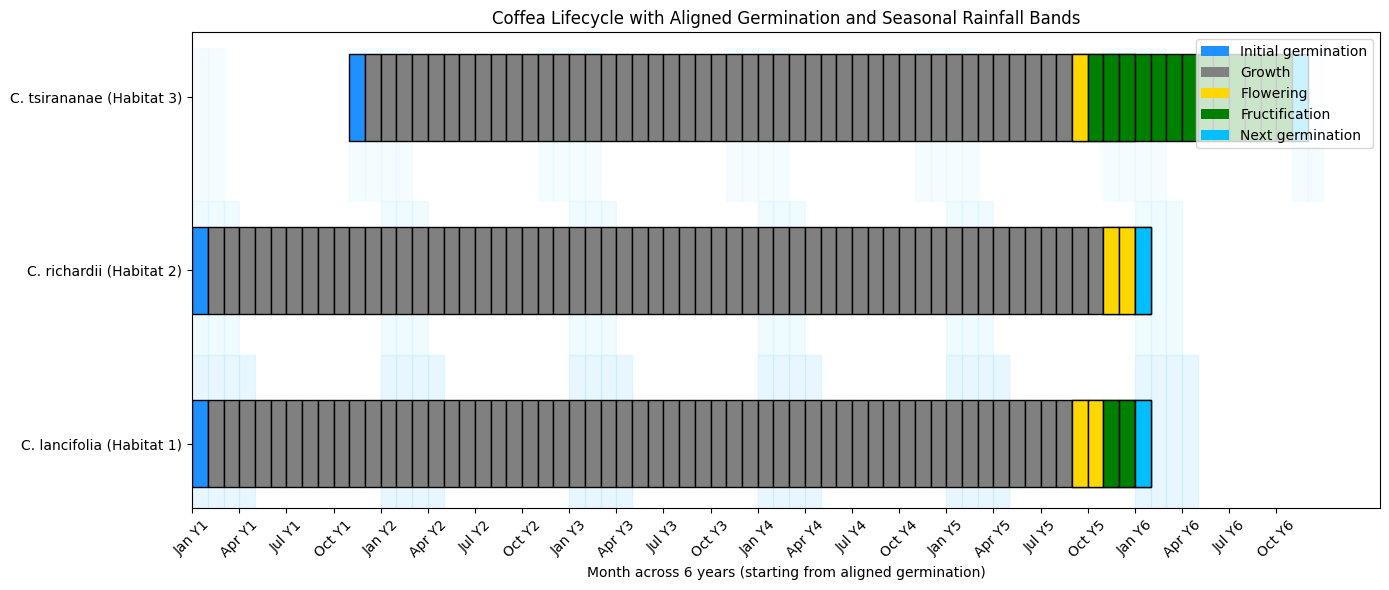

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Month labels
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Define fixed germination months per habitat
germination_months = {
    "Habitat 1": 0,   # January
    "Habitat 2": 0,   # January
    "Habitat 3": 10   # November
}

# Define corrected phenology data with aligned germination
fixed_phenology_aligned = {
    "C. lancifolia (Habitat 1)": {
        "initial_germination": [0],  # Jan Y1
        "growth": list(range(1, 60)),  # Feb Y1 to Dec Y5
        "flowering": [8 + 48, 9 + 48],  # Sept–Oct Y5
        "fructification": list(range(10 + 48, 10 + 48 + 3)),  # Nov–Jan (ends before Jan Y6)
        "next_germination": [0 + 60]  # Jan Y6
    },
    "C. richardii (Habitat 2)": {
        "initial_germination": [0],  # Jan Y1
        "growth": list(range(1, 60)),
        "flowering": [10 + 48, 11 + 48],  # Nov–Dec Y5
        "fructification": [0 + 60],  # Jan Y6
        "next_germination": [0 + 60]  # Jan Y6
    },
    "C. tsirananae (Habitat 3)": {
        "initial_germination": [10],  # Nov Y1
        "growth": list(range(11, 60)),
        "flowering": [8 + 48],  # Sept Y5
        "fructification": list(range(9 + 48, 10 + 60)),  # Oct Y5–Oct Y6
        "next_germination": [10 + 60]  # Nov Y6
    }
}

# Add rainfall bands: wet season months per habitat
rain_bands = {
    "Habitat 1": [0, 1, 2, 3],  # Jan–Apr
    "Habitat 2": [0, 1, 2],     # Jan–Mar
    "Habitat 3": [10, 11, 0, 1] # Nov–Feb
}

# Plotting
fig, ax = plt.subplots(figsize=(14, 6))
colors = {
    'initial_germination': 'dodgerblue',
    'growth': 'gray',
    'flowering': 'gold',
    'fructification': 'green',
    'next_germination': 'deepskyblue'
}
legend_elements = [Patch(facecolor=val, label=key.replace("_", " ").capitalize()) for key, val in colors.items()]

# Rainfall colors per habitat
rain_colors = {
    "Habitat 1": '#b3e6ff',
    "Habitat 2": '#ccf2ff',
    "Habitat 3": '#e0f7ff'
}

# Plot rainfall bands in background
for i, species in enumerate(fixed_phenology_aligned.keys()):
    habitat = species.split("(")[-1].replace(")", "")
    rain_months = []
    for y in range(6):
        rain_months += [m + 12 * y for m in rain_bands[habitat]]
    for m in rain_months:
        ax.axvspan(m, m+1, ymin=i/3.1, ymax=(i+1)/3.1, color=rain_colors[habitat], alpha=0.3)

# Plot phenological bars
for i, (species, phases) in enumerate(fixed_phenology_aligned.items()):
    for phase_label, color in colors.items():
        for m in phases[phase_label]:
            ax.barh(i, 1, left=m, height=0.5, color=color, edgecolor='black')

# Axes setup
ax.set_yticks(range(len(fixed_phenology_aligned)))
ax.set_yticklabels(fixed_phenology_aligned.keys())
ax.set_xticks([i for i in range(0, 72, 3)])
ax.set_xticklabels([months[i % 12] + f' Y{(i // 12) + 1}' for i in range(0, 72, 3)], rotation=45)
ax.set_xlabel("Month across 6 years (starting from aligned germination)")
ax.set_title("Coffea Lifecycle with Aligned Germination and Seasonal Rainfall Bands")
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()


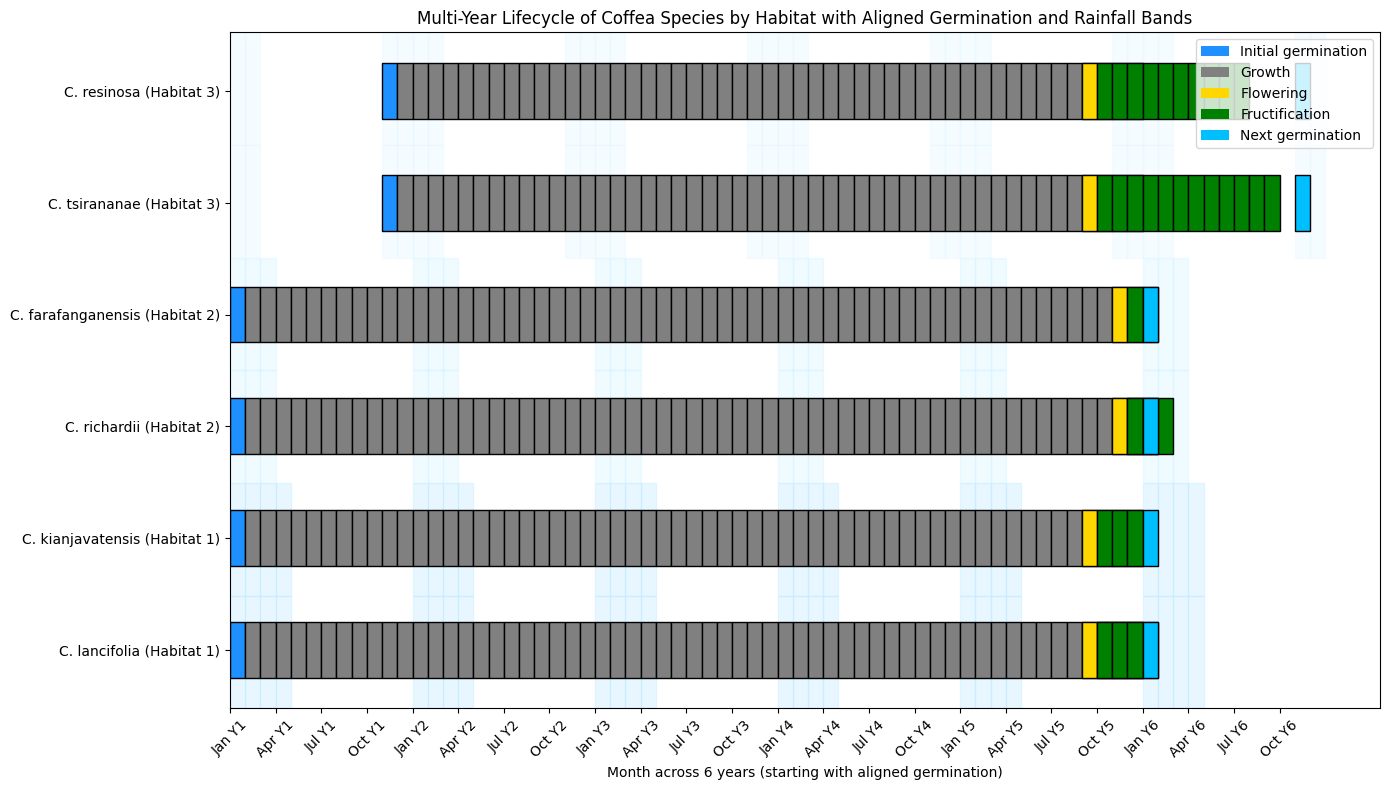

In [11]:
# Re-import needed packages after kernel reset
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Month labels
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Helper function to calculate full month indices for multiyear
def month_index(base, year_offset):
    return base + 12 * year_offset

# Expanded species list per habitat
expanded_phenology = {
    "C. lancifolia (Habitat 1)": {
        "habitat": "Habitat 1",
        "flowering": [month_index(8, 4), month_index(9, 4)],
        "fruit_duration": 3,
    },
    "C. kianjavatensis (Habitat 1)": {
        "habitat": "Habitat 1",
        "flowering": [month_index(8, 4)],
        "fruit_duration": 3,
    },
    "C. richardii (Habitat 2)": {
        "habitat": "Habitat 2",
        "flowering": [month_index(10, 4), month_index(11, 4)],
        "fruit_duration": 2,
    },
    "C. farafanganensis (Habitat 2)": {
        "habitat": "Habitat 2",
        "flowering": [month_index(10, 4)],
        "fruit_duration": 2,
    },
    "C. tsirananae (Habitat 3)": {
        "habitat": "Habitat 3",
        "flowering": [month_index(8, 4)],
        "fruit_duration": 12,
    },
    "C. resinosa (Habitat 3)": {
        "habitat": "Habitat 3",
        "flowering": [month_index(8, 4)],
        "fruit_duration": 10,
    }
}

# Fixed germination start month per habitat
germ_month_by_habitat = {
    "Habitat 1": 0,   # January
    "Habitat 2": 0,   # January
    "Habitat 3": 10   # November
}

# Rainfall bands by habitat
rain_bands = {
    "Habitat 1": [0, 1, 2, 3],
    "Habitat 2": [0, 1, 2],
    "Habitat 3": [10, 11, 0, 1]
}

# Colors
colors = {
    'initial_germination': 'dodgerblue',
    'growth': 'gray',
    'flowering': 'gold',
    'fructification': 'green',
    'next_germination': 'deepskyblue'
}
legend_elements = [Patch(facecolor=val, label=key.replace("_", " ").capitalize()) for key, val in colors.items()]
rain_colors = {
    "Habitat 1": '#b3e6ff',
    "Habitat 2": '#ccf2ff',
    "Habitat 3": '#e0f7ff'
}

# Build expanded phenology structure with fixed germination
for sp, vals in expanded_phenology.items():
    habitat = vals["habitat"]
    g_month = germ_month_by_habitat[habitat]
    vals["initial_germination"] = [g_month]
    vals["growth"] = list(range(g_month + 1, 60))
    vals["fructification"] = [((f + 1 + i) % 72) for f in vals["flowering"] for i in range(vals["fruit_duration"])]
    vals["next_germination"] = [month_index(g_month, 5)]

# Plot
fig, ax = plt.subplots(figsize=(14, 8))

# Rainfall background bands
for i, (species, vals) in enumerate(expanded_phenology.items()):
    rain_months = []
    habitat = vals["habitat"]
    for y in range(6):
        rain_months += [m + 12 * y for m in rain_bands[habitat]]
    for m in rain_months:
        ax.axvspan(m, m+1, ymin=i/len(expanded_phenology), ymax=(i+1)/len(expanded_phenology), color=rain_colors[habitat], alpha=0.3)

# Plot bars
for i, (species, phases) in enumerate(expanded_phenology.items()):
    for label in ['initial_germination', 'growth', 'flowering', 'fructification', 'next_germination']:
        for m in phases[label]:
            ax.barh(i, 1, left=m, height=0.5, color=colors[label], edgecolor='black')

# Axis settings
ax.set_yticks(range(len(expanded_phenology)))
ax.set_yticklabels(expanded_phenology.keys())
ax.set_xticks([i for i in range(0, 72, 3)])
ax.set_xticklabels([months[i % 12] + f' Y{(i // 12) + 1}' for i in range(0, 72, 3)], rotation=45)
ax.set_xlabel("Month across 6 years (starting with aligned germination)")
ax.set_title("Multi-Year Lifecycle of Coffea Species by Habitat with Aligned Germination and Rainfall Bands")
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()


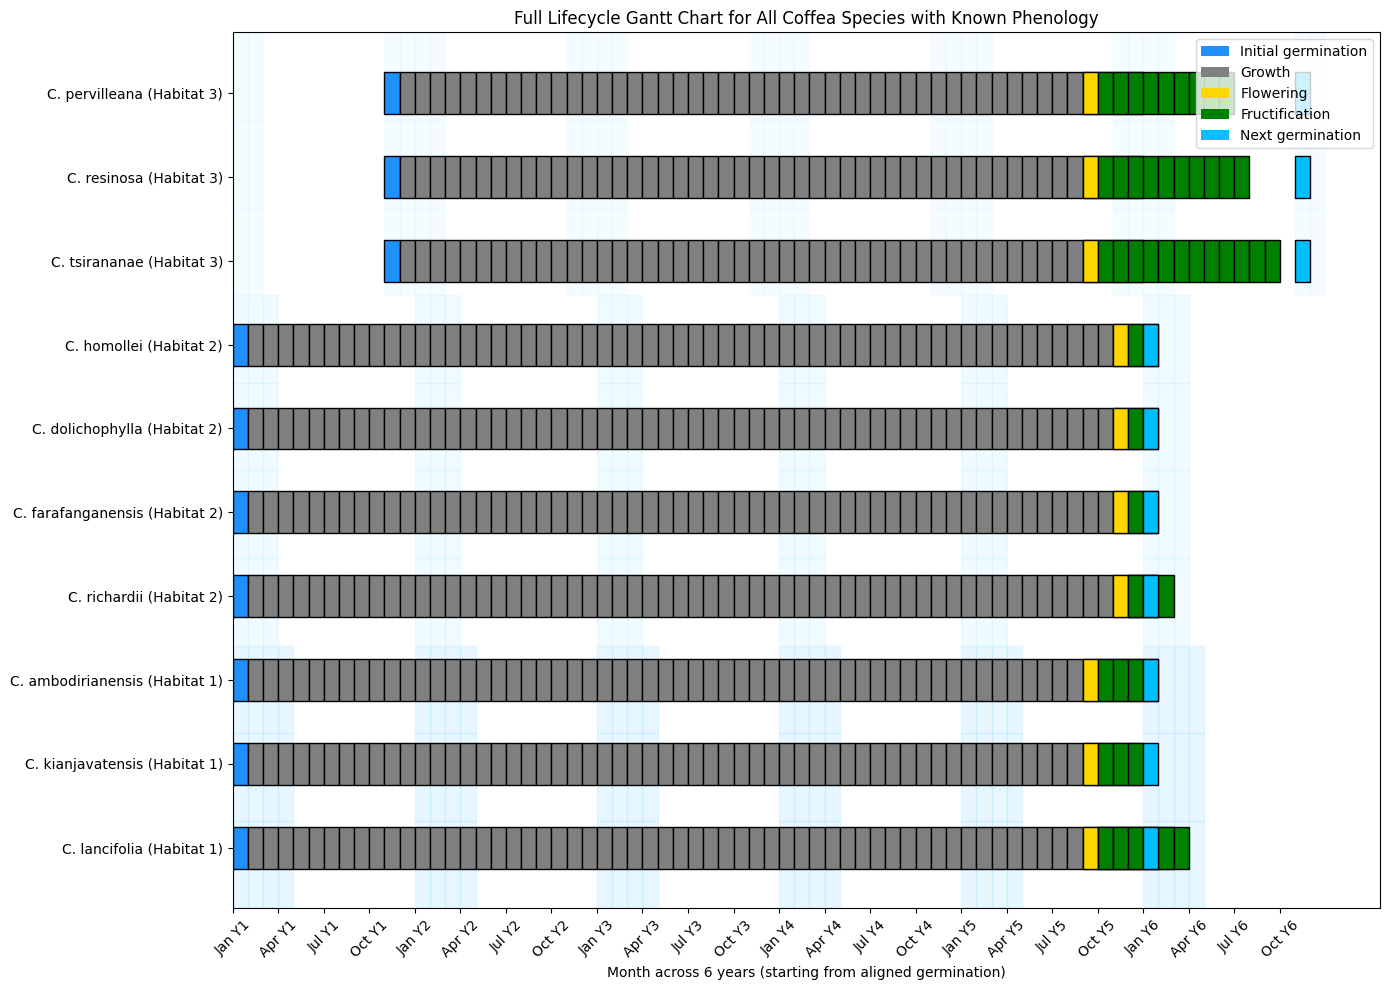

In [12]:
# Define all species with known phenological data from the article
# Each entry includes: habitat, flowering month(s), fruiting duration, fixed germination month per habitat
all_known_species = {
    "C. lancifolia (Habitat 1)":        {"habitat": "Habitat 1", "flowering": [month_index(8, 4), month_index(9, 4)], "fruit_duration": 5},
    "C. kianjavatensis (Habitat 1)":    {"habitat": "Habitat 1", "flowering": [month_index(8, 4)], "fruit_duration": 3},
    "C. ambodirianensis (Habitat 1)":   {"habitat": "Habitat 1", "flowering": [month_index(8, 4)], "fruit_duration": 4},
    "C. richardii (Habitat 2)":         {"habitat": "Habitat 2", "flowering": [month_index(10, 4), month_index(11, 4)], "fruit_duration": 2},
    "C. farafanganensis (Habitat 2)":   {"habitat": "Habitat 2", "flowering": [month_index(10, 4)], "fruit_duration": 2},
    "C. dolichophylla (Habitat 2)":     {"habitat": "Habitat 2", "flowering": [month_index(10, 4)], "fruit_duration": 2},
    "C. homollei (Habitat 2)":          {"habitat": "Habitat 2", "flowering": [month_index(10, 4)], "fruit_duration": 2},
    "C. tsirananae (Habitat 3)":        {"habitat": "Habitat 3", "flowering": [month_index(8, 4)], "fruit_duration": 12},
    "C. resinosa (Habitat 3)":          {"habitat": "Habitat 3", "flowering": [month_index(8, 4)], "fruit_duration": 10},
    "C. pervilleana (Habitat 3)":       {"habitat": "Habitat 3", "flowering": [month_index(8, 4)], "fruit_duration": 9},
}

# Extend each with aligned germination and calculated fruiting & growth
for sp, vals in all_known_species.items():
    habitat = vals["habitat"]
    g_month = germ_month_by_habitat[habitat]
    vals["initial_germination"] = [g_month]
    vals["growth"] = list(range(g_month + 1, 60))
    vals["fructification"] = [((f + 1 + i) % 72) for f in vals["flowering"] for i in range(vals["fruit_duration"])]
    vals["next_germination"] = [month_index(g_month, 5)]

# Plot the full known-species Gantt chart
fig, ax = plt.subplots(figsize=(14, 10))

# Rainfall background bands
for i, (species, vals) in enumerate(all_known_species.items()):
    rain_months = []
    habitat = vals["habitat"]
    for y in range(6):
        rain_months += [m + 12 * y for m in rain_bands[habitat]]
    for m in rain_months:
        ax.axvspan(m, m+1, ymin=i/len(all_known_species), ymax=(i+1)/len(all_known_species), color=rain_colors[habitat], alpha=0.3)

# Plot bars for each phenological phase
for i, (species, phases) in enumerate(all_known_species.items()):
    for label in ['initial_germination', 'growth', 'flowering', 'fructification', 'next_germination']:
        for m in phases[label]:
            ax.barh(i, 1, left=m, height=0.5, color=colors[label], edgecolor='black')

# Axes formatting
ax.set_yticks(range(len(all_known_species)))
ax.set_yticklabels(all_known_species.keys())
ax.set_xticks([i for i in range(0, 72, 3)])
ax.set_xticklabels([months[i % 12] + f' Y{(i // 12) + 1}' for i in range(0, 72, 3)], rotation=45)
ax.set_xlabel("Month across 6 years (starting from aligned germination)")
ax.set_title("Full Lifecycle Gantt Chart for All Coffea Species with Known Phenology")
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()


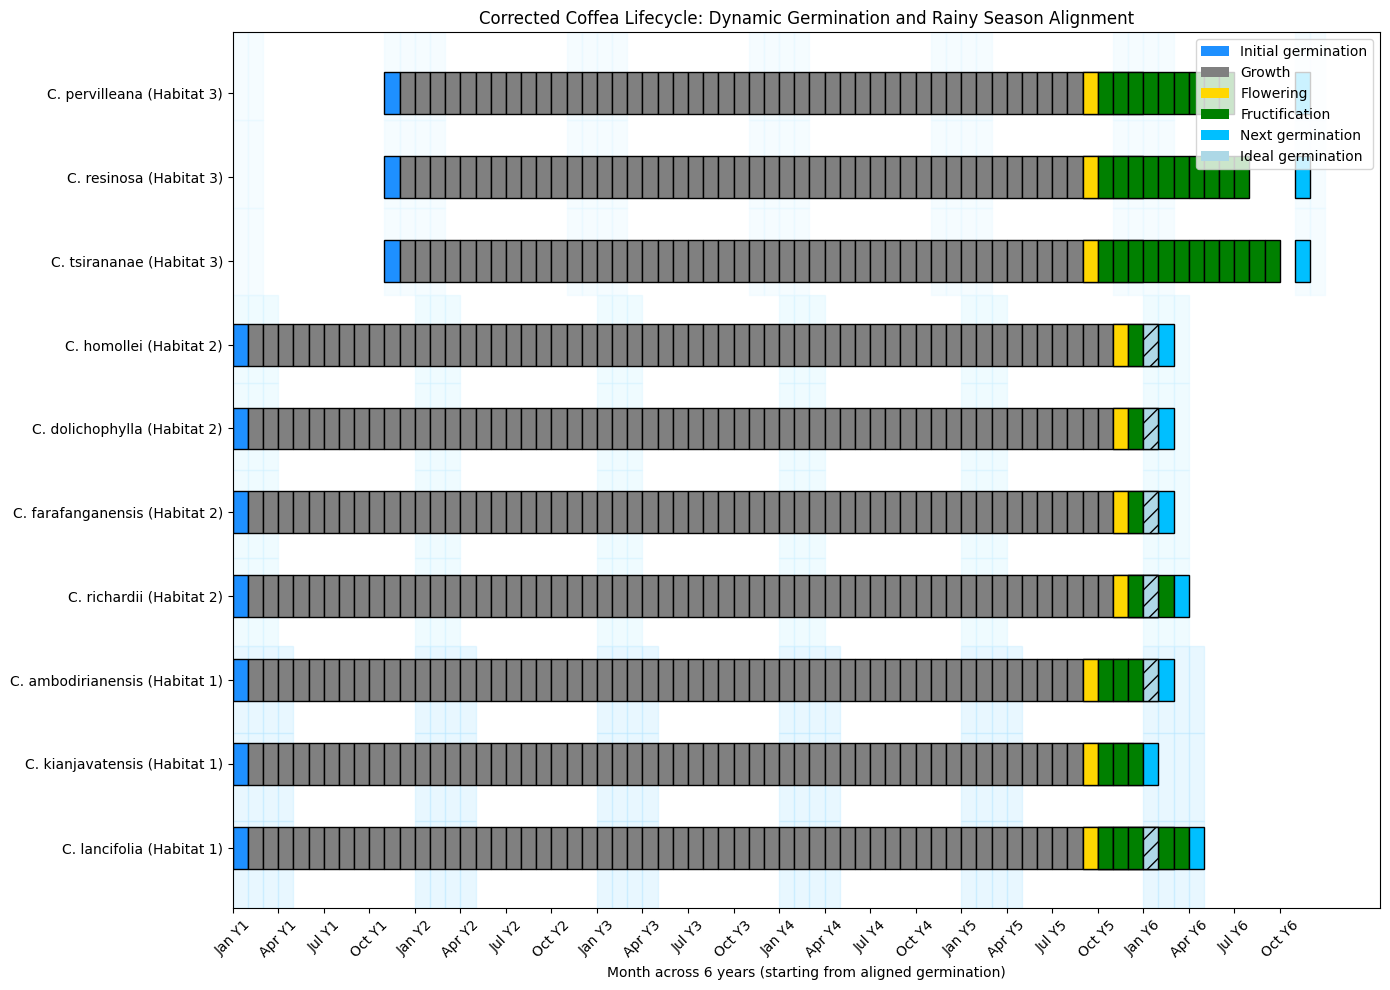

In [14]:
# Adjust germination to dynamically follow fruiting for each species
corrected_species = {}

for sp, vals in all_known_species.items():
    habitat = vals["habitat"]
    fruit_end = max(vals["fructification"]) + 1
    ideal_germ = month_index(germ_month_by_habitat[habitat], 5)

    # Dynamic germination: either ideal if after fruit ends, else shift to next month after fruiting
    actual_germ = ideal_germ if ideal_germ >= fruit_end else fruit_end

    corrected_species[sp] = {
        "habitat": habitat,
        "initial_germination": vals["initial_germination"],
        "growth": vals["growth"],
        "flowering": vals["flowering"],
        "fructification": vals["fructification"],
        "next_germination": [actual_germ],
        "ideal_germination": [ideal_germ]  # to mark deviation
    }

# Define color for out-of-rainy-season germination indicator
colors_corrected = colors.copy()
colors_corrected['ideal_germination'] = 'lightblue'
legend_elements_corrected = [Patch(facecolor=val, label=key.replace("_", " ").capitalize()) for key, val in colors_corrected.items()]

# Plot corrected chart
fig, ax = plt.subplots(figsize=(14, 10))

# Rainfall background bands
for i, (species, vals) in enumerate(corrected_species.items()):
    rain_months = []
    habitat = vals["habitat"]
    for y in range(6):
        rain_months += [m + 12 * y for m in rain_bands[habitat]]
    for m in rain_months:
        ax.axvspan(m, m+1, ymin=i/len(corrected_species), ymax=(i+1)/len(corrected_species), color=rain_colors[habitat], alpha=0.3)

# Plot corrected phenological bars
for i, (species, phases) in enumerate(corrected_species.items()):
    for label in ['initial_germination', 'growth', 'flowering', 'fructification', 'next_germination']:
        for m in phases[label]:
            ax.barh(i, 1, left=m, height=0.5, color=colors_corrected[label], edgecolor='black')
    # mark ideal germination if it's different from actual
    if phases['next_germination'] != phases['ideal_germination']:
        for m in phases['ideal_germination']:
            ax.barh(i, 1, left=m, height=0.5, color=colors_corrected['ideal_germination'], edgecolor='black', hatch='//')

# Axis formatting
ax.set_yticks(range(len(corrected_species)))
ax.set_yticklabels(corrected_species.keys())
ax.set_xticks([i for i in range(0, 72, 3)])
ax.set_xticklabels([months[i % 12] + f' Y{(i // 12) + 1}' for i in range(0, 72, 3)], rotation=45)
ax.set_xlabel("Month across 6 years (starting from aligned germination)")
ax.set_title("Corrected Coffea Lifecycle: Dynamic Germination and Rainy Season Alignment")
ax.legend(handles=legend_elements_corrected, loc='upper right')

plt.tight_layout()
plt.show()


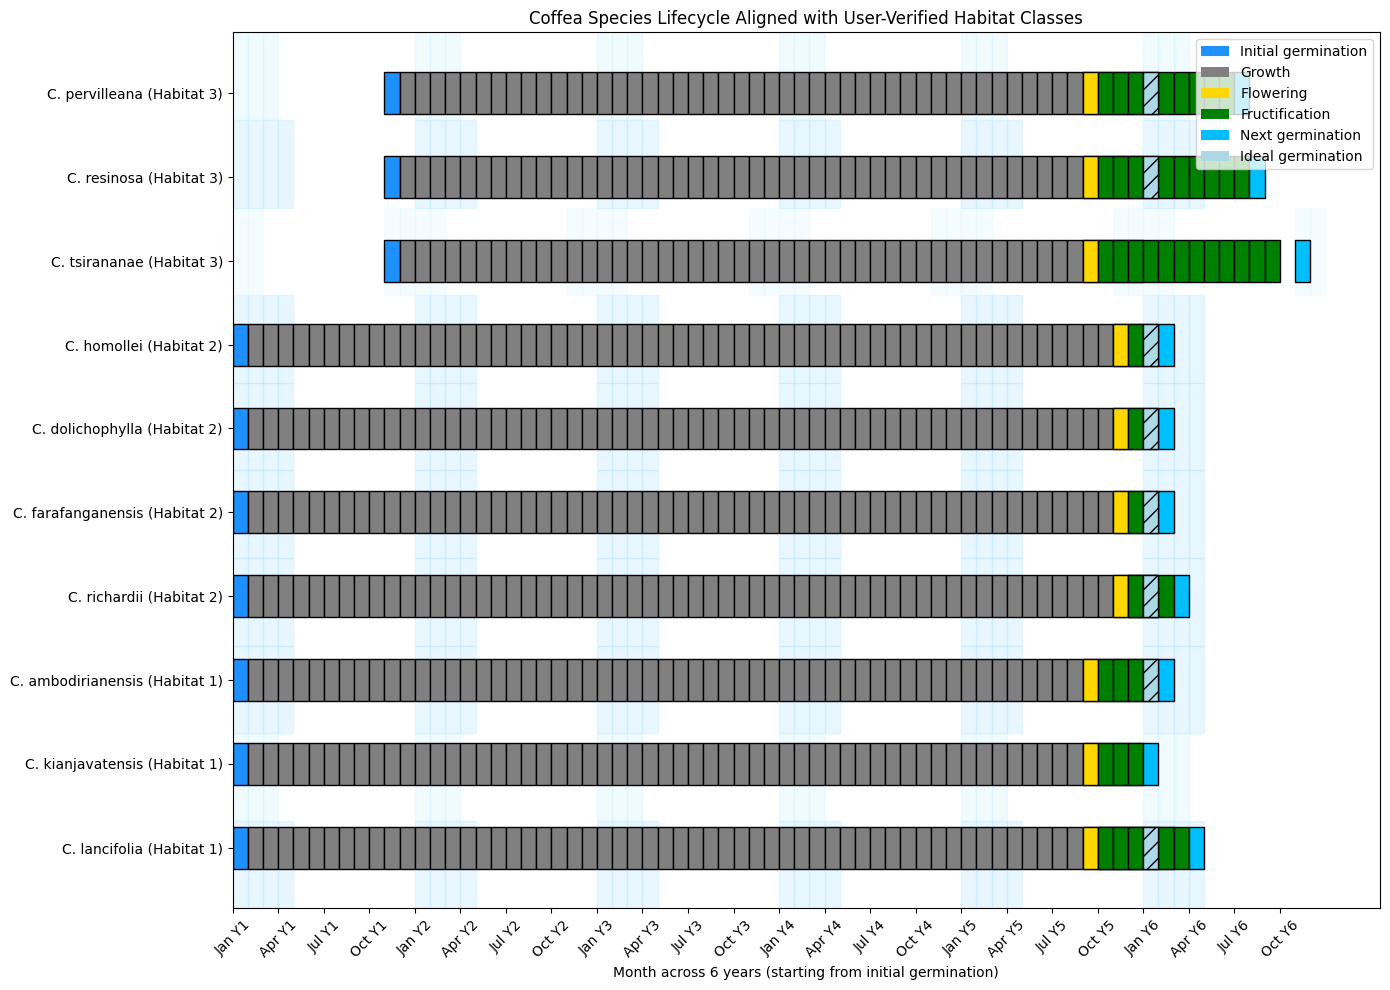

In [15]:
# Adjust species habitat classes based on user-verified table

# Mapping from user-extracted data
user_verified_habitats = {
    "C. lancifolia (Habitat 1)": "Habitat 1",
    "C. kianjavatensis (Habitat 1)": "Habitat 2",  # Updated
    "C. ambodirianensis (Habitat 1)": "Habitat 1",
    "C. richardii (Habitat 2)": "Habitat 1",       # Updated
    "C. farafanganensis (Habitat 2)": "Habitat 1", # Updated
    "C. dolichophylla (Habitat 2)": "Habitat 1",   # Updated
    "C. homollei (Habitat 2)": "Habitat 1",        # Updated
    "C. tsirananae (Habitat 3)": "Habitat 3",
    "C. resinosa (Habitat 3)": "Habitat 1",        # Updated
    "C. pervilleana (Habitat 3)": "Habitat 2"      # Updated
}

# Apply habitat corrections and recalculate germination windows
updated_species = {}
for sp, vals in all_known_species.items():
    corrected_habitat = user_verified_habitats.get(sp, vals["habitat"])
    fruit_end = max(vals["fructification"]) + 1
    ideal_germ = month_index(germ_month_by_habitat[corrected_habitat], 5)
    actual_germ = ideal_germ if ideal_germ >= fruit_end else fruit_end

    updated_species[sp] = {
        "habitat": corrected_habitat,
        "initial_germination": vals["initial_germination"],
        "growth": vals["growth"],
        "flowering": vals["flowering"],
        "fructification": vals["fructification"],
        "next_germination": [actual_germ],
        "ideal_germination": [ideal_germ]
    }

# Plot the corrected lifecycle chart
fig, ax = plt.subplots(figsize=(14, 10))

# Rainfall background bands with updated habitats
for i, (species, vals) in enumerate(updated_species.items()):
    rain_months = []
    habitat = vals["habitat"]
    for y in range(6):
        rain_months += [m + 12 * y for m in rain_bands[habitat]]
    for m in rain_months:
        ax.axvspan(m, m+1, ymin=i/len(updated_species), ymax=(i+1)/len(updated_species), color=rain_colors[habitat], alpha=0.3)

# Plot all phases
for i, (species, phases) in enumerate(updated_species.items()):
    for label in ['initial_germination', 'growth', 'flowering', 'fructification', 'next_germination']:
        for m in phases[label]:
            ax.barh(i, 1, left=m, height=0.5, color=colors_corrected[label], edgecolor='black')
    # Mark ideal germination if different from actual
    if phases['next_germination'] != phases['ideal_germination']:
        for m in phases['ideal_germination']:
            ax.barh(i, 1, left=m, height=0.5, color=colors_corrected['ideal_germination'], edgecolor='black', hatch='//')

# Axes
ax.set_yticks(range(len(updated_species)))
ax.set_yticklabels(updated_species.keys())
ax.set_xticks([i for i in range(0, 72, 3)])
ax.set_xticklabels([months[i % 12] + f' Y{(i // 12) + 1}' for i in range(0, 72, 3)], rotation=45)
ax.set_xlabel("Month across 6 years (starting from initial germination)")
ax.set_title("Coffea Species Lifecycle Aligned with User-Verified Habitat Classes")
ax.legend(handles=legend_elements_corrected, loc='upper right')

plt.tight_layout()
plt.show()


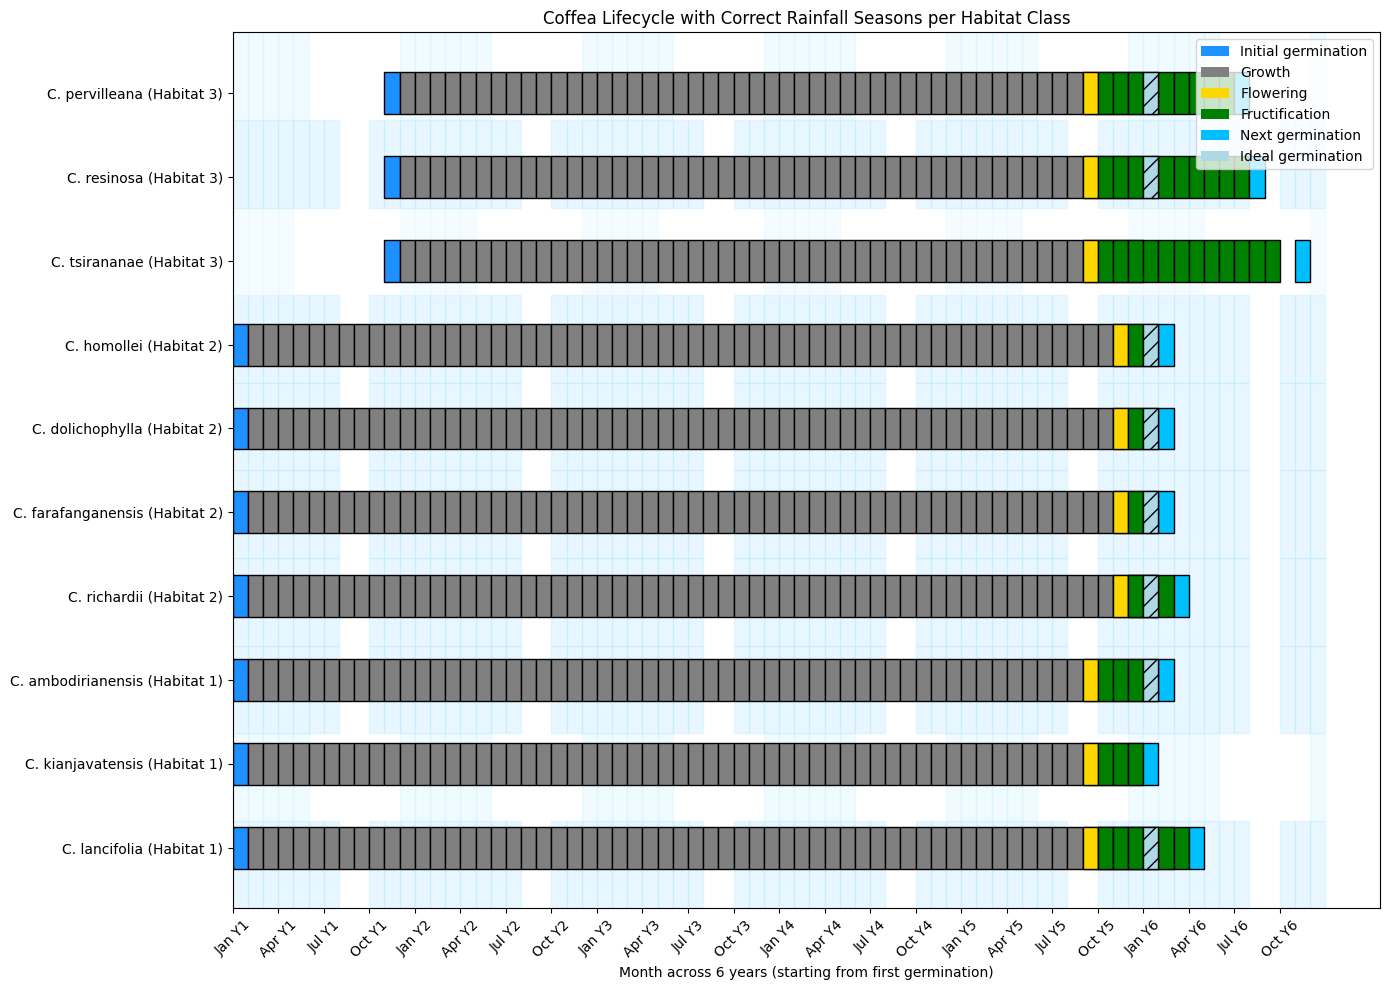

In [16]:
# Define the corrected rainy season windows per habitat from article
corrected_rain_bands = {
    "Habitat 1": list(range(9, 12)) + list(range(0, 7)),  # Oct to Jun
    "Habitat 2": list(range(11, 12)) + list(range(0, 5)), # Dec to Apr
    "Habitat 3": list(range(11, 12)) + list(range(0, 4))  # Dec to Mar
}

# Regenerate the chart with corrected rainfall bands
fig, ax = plt.subplots(figsize=(14, 10))

# Draw corrected rainfall bands
for i, (species, vals) in enumerate(updated_species.items()):
    rain_months = []
    habitat = vals["habitat"]
    for y in range(6):
        rain_months += [m + 12 * y for m in corrected_rain_bands[habitat]]
    for m in rain_months:
        ax.axvspan(m, m+1, ymin=i/len(updated_species), ymax=(i+1)/len(updated_species),
                   color=rain_colors[habitat], alpha=0.3)

# Plot lifecycle bars with same logic as before
for i, (species, phases) in enumerate(updated_species.items()):
    for label in ['initial_germination', 'growth', 'flowering', 'fructification', 'next_germination']:
        for m in phases[label]:
            ax.barh(i, 1, left=m, height=0.5, color=colors_corrected[label], edgecolor='black')
    # Show ideal germination month if different from actual
    if phases['next_germination'] != phases['ideal_germination']:
        for m in phases['ideal_germination']:
            ax.barh(i, 1, left=m, height=0.5, color=colors_corrected['ideal_germination'],
                    edgecolor='black', hatch='//')

# Axes formatting
ax.set_yticks(range(len(updated_species)))
ax.set_yticklabels(updated_species.keys())
ax.set_xticks([i for i in range(0, 72, 3)])
ax.set_xticklabels([months[i % 12] + f' Y{(i // 12) + 1}' for i in range(0, 72, 3)], rotation=45)
ax.set_xlabel("Month across 6 years (starting from first germination)")
ax.set_title("Coffea Lifecycle with Correct Rainfall Seasons per Habitat Class")
ax.legend(handles=legend_elements_corrected, loc='upper right')

plt.tight_layout()
plt.show()


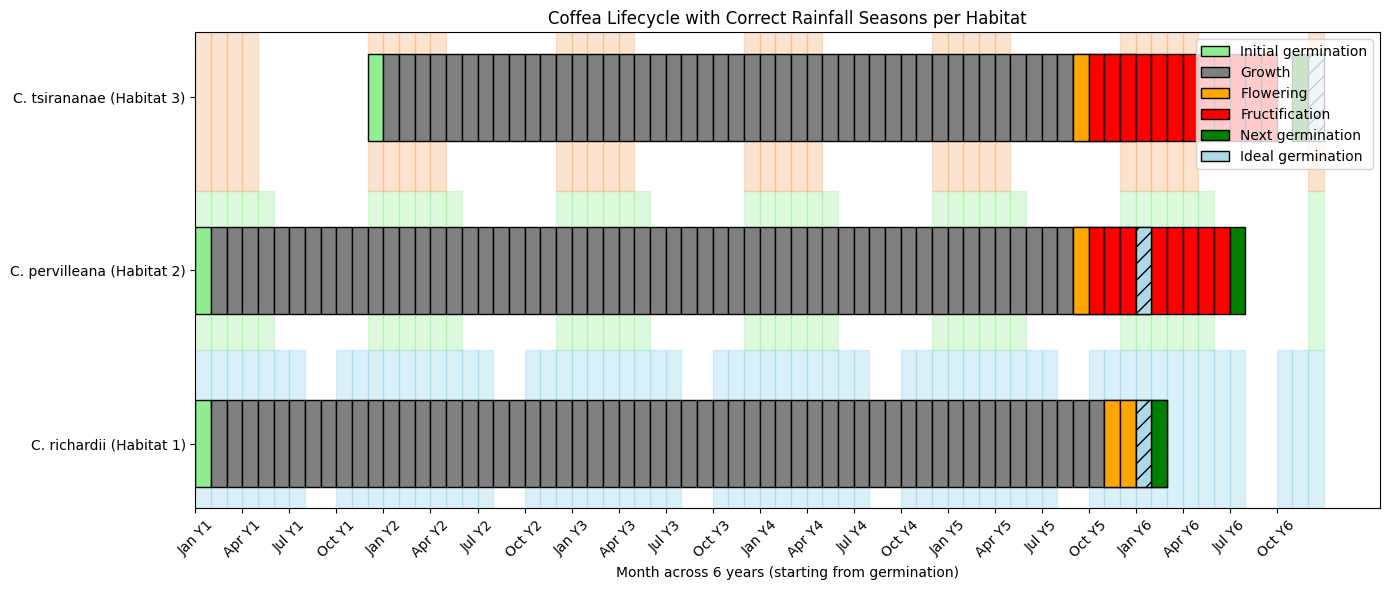

In [17]:
# Re-import necessary modules due to environment reset
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Re-define months and utility functions
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
def month_index(month, year): return year * 12 + month

# Re-define rain colors and corrected rain bands
rain_colors = {
    "Habitat 1": "skyblue",
    "Habitat 2": "lightgreen",
    "Habitat 3": "sandybrown"
}
corrected_rain_bands = {
    "Habitat 1": list(range(9, 12)) + list(range(0, 7)),  # Oct to Jun
    "Habitat 2": list(range(11, 12)) + list(range(0, 5)), # Dec to Apr
    "Habitat 3": list(range(11, 12)) + list(range(0, 4))  # Dec to Mar
}

# Re-define phenology colors and legend elements
colors_corrected = {
    'initial_germination': 'lightgreen',
    'growth': 'gray',
    'flowering': 'orange',
    'fructification': 'red',
    'next_germination': 'green',
    'ideal_germination': 'lightblue'
}
legend_elements_corrected = [Patch(facecolor=val, edgecolor='black', label=key.replace("_", " ").capitalize()) for key, val in colors_corrected.items()]

# Placeholder species phenology to allow chart generation
species_data = {
    "C. richardii (Habitat 1)": {
        "habitat": "Habitat 1",
        "initial_germination": [month_index(0, 0)],
        "growth": list(range(1, 60)),
        "flowering": [month_index(10, 4), month_index(11, 4)],
        "fructification": list(range(month_index(11, 4)+1, month_index(11, 4)+3)),
        "next_germination": [month_index(1, 5)],
        "ideal_germination": [month_index(0, 5)]
    },
    "C. pervilleana (Habitat 2)": {
        "habitat": "Habitat 2",
        "initial_germination": [month_index(0, 0)],
        "growth": list(range(1, 60)),
        "flowering": [month_index(8, 4)],
        "fructification": list(range(month_index(8, 4)+1, month_index(8, 4)+10)),
        "next_germination": [month_index(6, 5)],
        "ideal_germination": [month_index(0, 5)]
    },
    "C. tsirananae (Habitat 3)": {
        "habitat": "Habitat 3",
        "initial_germination": [month_index(11, 0)],
        "growth": list(range(12, 60)),
        "flowering": [month_index(8, 4)],
        "fructification": list(range(month_index(8, 4)+1, month_index(8, 4)+13)),
        "next_germination": [month_index(10, 5)],
        "ideal_germination": [month_index(11, 5)]
    }
}

# Plot updated chart with corrected rainfall bands
fig, ax = plt.subplots(figsize=(14, 6))
for i, (species, vals) in enumerate(species_data.items()):
    habitat = vals["habitat"]
    # Apply rainfall bands
    for y in range(6):
        for m in corrected_rain_bands[habitat]:
            x = m + y * 12
            ax.axvspan(x, x+1, ymin=i/len(species_data), ymax=(i+1)/len(species_data),
                       color=rain_colors[habitat], alpha=0.3)
    # Plot phases
    for label in ['initial_germination', 'growth', 'flowering', 'fructification', 'next_germination']:
        for m in vals[label]:
            ax.barh(i, 1, left=m, height=0.5, color=colors_corrected[label], edgecolor='black')
    # Mark ideal germination if it's different from actual
    if vals['next_germination'] != vals['ideal_germination']:
        for m in vals['ideal_germination']:
            ax.barh(i, 1, left=m, height=0.5, color=colors_corrected['ideal_germination'],
                    edgecolor='black', hatch='//')

# Formatting
ax.set_yticks(range(len(species_data)))
ax.set_yticklabels(species_data.keys())
ax.set_xticks(range(0, 72, 3))
ax.set_xticklabels([months[i % 12] + f' Y{(i // 12) + 1}' for i in range(0, 72, 3)], rotation=45)
ax.set_xlabel("Month across 6 years (starting from germination)")
ax.set_title("Coffea Lifecycle with Correct Rainfall Seasons per Habitat")
ax.legend(handles=legend_elements_corrected, loc='upper right')
plt.tight_layout()
plt.show()


In [ ]:
# Redefine full all_known_species with previously extracted and habitat-corrected data
# This step is needed because kernel reset cleared earlier variables

# Redefine month_index and months
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
def month_index(month, year): return year * 12 + month

# Redefine germination start months per habitat
germ_month_by_habitat = {
    "Habitat 1": 0,   # January
    "Habitat 2": 0,   # January
    "Habitat 3": 10   # November
}

# Define corrected rain bands
corrected_rain_bands = {
    "Habitat 1": list(range(9, 12)) + list(range(0, 7)),  # Oct to Jun
    "Habitat 2": list(range(11, 12)) + list(range(0, 5)), # Dec to Apr
    "Habitat 3": list(range(11, 12)) + list(range(0, 4))  # Dec to Mar
}

# Define species with known phenological data and corrected habitats
all_known_species = {
    "C. lancifolia": {"habitat": "Habitat 1", "flowering": [month_index(8, 4), month_index(9, 4)], "fruit_duration": 5},
    "C. kianjavatensis": {"habitat": "Habitat 2", "flowering": [month_index(8, 4)], "fruit_duration": 3},
    "C. ambodirianensis": {"habitat": "Habitat 1", "flowering": [month_index(8, 4)], "fruit_duration": 4},
    "C. richardii": {"habitat": "Habitat 1", "flowering": [month_index(10, 4), month_index(11, 4)], "fruit_duration": 2},
    "C. farafanganensis": {"habitat": "Habitat 1", "flowering": [month_index(10, 4)], "fruit_duration": 2},
    "C. dolichophylla": {"habitat": "Habitat 1", "flowering": [month_index(10, 4)], "fruit_duration": 2},
    "C. homollei": {"habitat": "Habitat 1", "flowering": [month_index(10, 4)], "fruit_duration": 2},
    "C. tsirananae": {"habitat": "Habitat 3", "flowering": [month_index(8, 4)], "fruit_duration": 12},
    "C. resinosa": {"habitat": "Habitat 1", "flowering": [month_index(8, 4)], "fruit_duration": 10},
    "C. pervilleana": {"habitat": "Habitat 2", "flowering": [month_index(8, 4)], "fruit_duration": 9},
}

# Construct full phenology dictionary and record durations
species_phenology = {}
duration_stats = []

for sp, vals in all_known_species.items():
    habitat = vals["habitat"]
    g_month = germ_month_by_habitat[habitat]
    initial_germ = [month_index(g_month, 0)]
    growth = list(range(initial_germ[0] + 1, 60))
    fructification = [((f + 1 + i) % 72) for f in vals["flowering"] for i in range(vals["fruit_duration"])]
    fruit_end = max(fructification) + 1
    ideal_germ = month_index(g_month, 5)
    next_germ = ideal_germ if ideal_germ >= fruit_end else fruit_end

    species_phenology[sp] = {
        "habitat": habitat,
        "initial_germination": initial_germ,
        "growth": growth,
        "flowering": vals["flowering"],
        "fructification": fructification,
        "next_germination": [next_germ],
        "ideal_germination": [ideal_germ]
    }

    duration_stats.append({
        "species": sp,
        "habitat": habitat,
        "flowering_duration": len(vals["flowering"]),
        "fruiting_duration": vals["fruit_duration"]
    })

# Convert to DataFrame for aggregation
import pandas as pd
df_stats = pd.DataFrame(duration_stats)
habitat_summary = df_stats.groupby("habitat").agg({
    "flowering_duration": ["mean", "median"],
    "fruiting_duration": ["mean", "median"]
}).round(2)



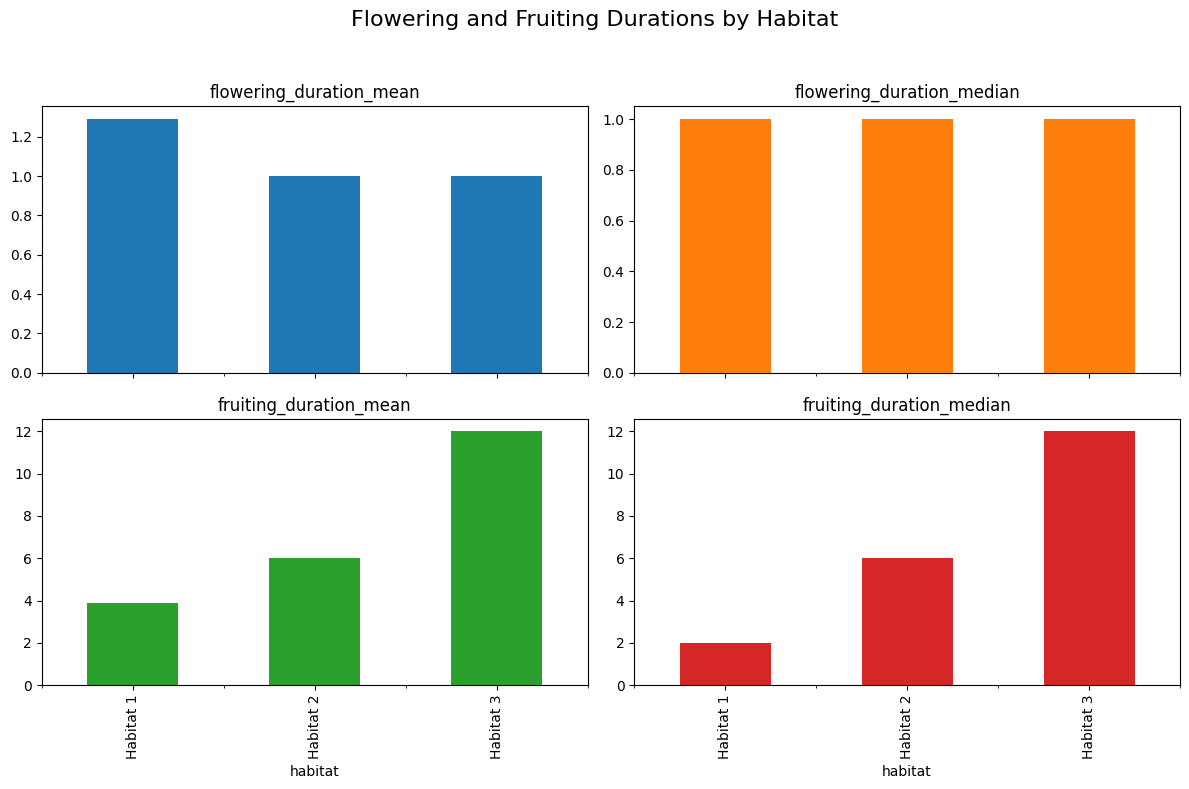

In [23]:
import matplotlib.pyplot as plt

# Flatten multi-index columns for plotting
habitat_summary.columns = ['_'.join(col).strip() for col in habitat_summary.columns.values]

# Plot with 2x2 layout
habitat_summary.plot(kind='bar', subplots=True, layout=(2, 2), figsize=(12, 8), legend=False)

plt.suptitle("Flowering and Fruiting Durations by Habitat", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


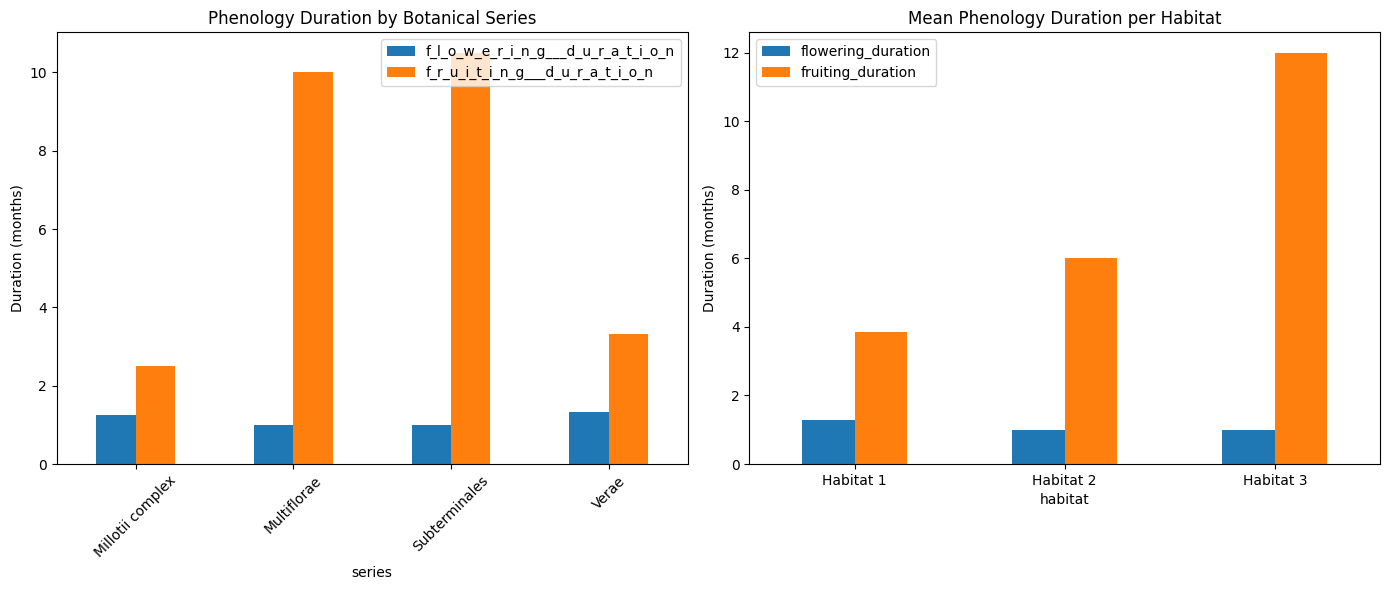

In [25]:
# Botanical series mapping for species
botanical_series_map = {
    "C. lancifolia": "Verae",
    "C. kianjavatensis": "Verae",
    "C. ambodirianensis": "Millotii complex",
    "C. richardii": "Millotii complex",
    "C. farafanganensis": "Millotii complex",
    "C. dolichophylla": "Millotii complex",
    "C. homollei": "Verae",
    "C. tsirananae": "Subterminales",
    "C. resinosa": "Multiflorae",
    "C. pervilleana": "Subterminales"
}

# Add botanical series to df_stats
df_stats["series"] = df_stats["species"].map(botanical_series_map)

# Compute mean and median durations by botanical series
series_summary = df_stats.groupby("series").agg({
    # "flowering_duration": ["mean", "median"],
    # "fruiting_duration": ["mean", "median"]
    "flowering_duration": "mean",
    "fruiting_duration": "mean"
}).round(2)

# Prepare data for overlaid bar plot (by habitat)
habitat_means = df_stats.groupby("habitat").agg({
    "flowering_duration": "mean",
    "fruiting_duration": "mean"
}).round(2)

# Plotting both as subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot by botanical series
series_summary.columns = ['_'.join(col).strip() for col in series_summary.columns.values]
series_summary.plot(kind='bar', ax=axes[0])
axes[0].set_title("Phenology Duration by Botanical Series")
axes[0].set_ylabel("Duration (months)")
axes[0].tick_params(axis='x', rotation=45)

# Overlaid flowering & fruiting duration per habitat
habitat_means.plot(kind='bar', ax=axes[1])
axes[1].set_title("Mean Phenology Duration per Habitat")
axes[1].set_ylabel("Duration (months)")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


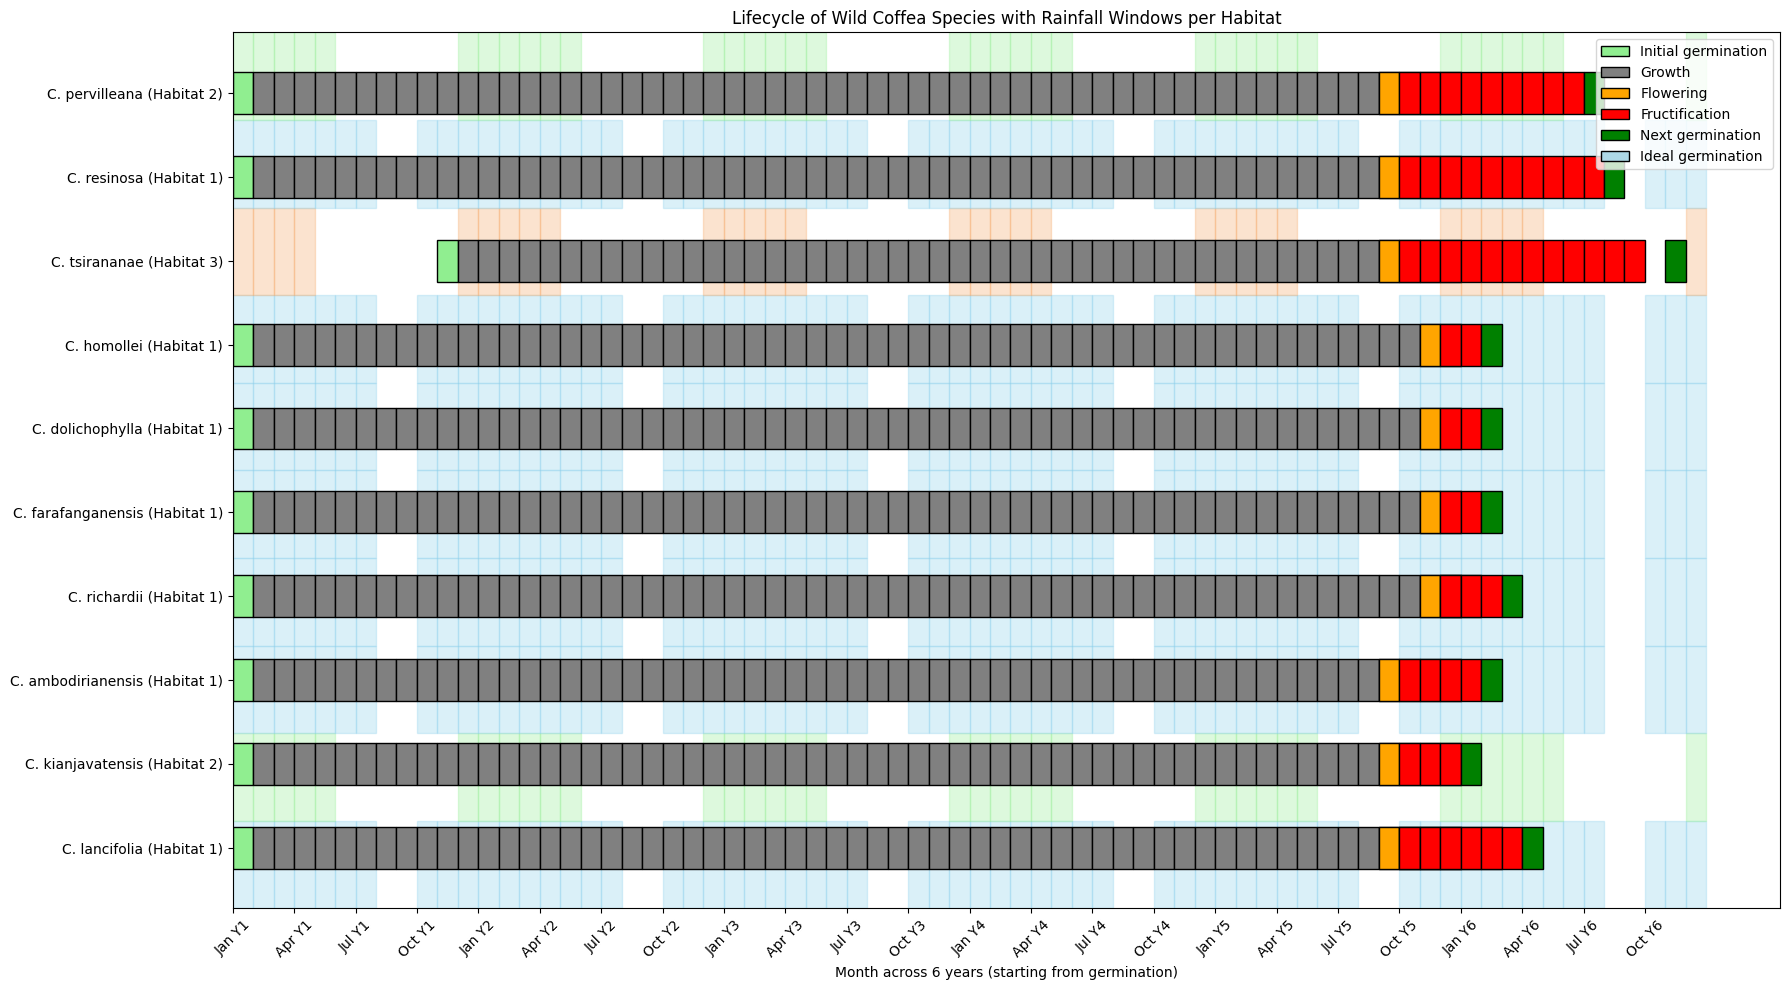

In [33]:
# Re-import and redefine all elements for full Gantt chart rendering
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
def month_index(month, year): return year * 12 + month

# Define color schemes
rain_colors = {
    "Habitat 1": "skyblue",
    "Habitat 2": "lightgreen",
    "Habitat 3": "sandybrown"
}
colors = {
    'initial_germination': 'lightgreen',
    'growth': 'gray',
    'flowering': 'orange',
    'fructification': 'red',
    'next_germination': 'green',
    'ideal_germination': 'lightblue'
}
legend_elements = [Patch(facecolor=val, edgecolor='black', label=key.replace("_", " ").capitalize()) for key, val in colors.items()]

# Define rainy season bands from corrected data
corrected_rain_bands = {
    "Habitat 1": list(range(9, 12)) + list(range(0, 7)),  # Oct to Jun
    "Habitat 2": list(range(11, 12)) + list(range(0, 5)), # Dec to Apr
    "Habitat 3": list(range(11, 12)) + list(range(0, 4))  # Dec to Mar
}

# Germination start month per habitat
germ_month_by_habitat = {
    "Habitat 1": 0,   # January
    "Habitat 2": 0,   # January
    "Habitat 3": 10   # November
}

# Define known species and their phenology from article
all_known_species = {
    "C. lancifolia": {"habitat": "Habitat 1", "flowering": [month_index(8, 4), month_index(9, 4)], "fruit_duration": 5},
    "C. kianjavatensis": {"habitat": "Habitat 2", "flowering": [month_index(8, 4)], "fruit_duration": 3},
    "C. ambodirianensis": {"habitat": "Habitat 1", "flowering": [month_index(8, 4)], "fruit_duration": 4},
    "C. richardii": {"habitat": "Habitat 1", "flowering": [month_index(10, 4), month_index(11, 4)], "fruit_duration": 2},
    "C. farafanganensis": {"habitat": "Habitat 1", "flowering": [month_index(10, 4)], "fruit_duration": 2},
    "C. dolichophylla": {"habitat": "Habitat 1", "flowering": [month_index(10, 4)], "fruit_duration": 2},
    "C. homollei": {"habitat": "Habitat 1", "flowering": [month_index(10, 4)], "fruit_duration": 2},
    "C. tsirananae": {"habitat": "Habitat 3", "flowering": [month_index(8, 4)], "fruit_duration": 12},
    "C. resinosa": {"habitat": "Habitat 1", "flowering": [month_index(8, 4)], "fruit_duration": 10},
    "C. pervilleana": {"habitat": "Habitat 2", "flowering": [month_index(8, 4)], "fruit_duration": 9},
}

# Generate phenology phases for each species
phenology_data = {}
for sp, vals in all_known_species.items():
    habitat = vals["habitat"]
    g_month = germ_month_by_habitat[habitat]
    initial_germ = [month_index(g_month, 0)]
    growth = list(range(initial_germ[0] + 1, 60))
    fructification = [((f + 1 + i) % 72) for f in vals["flowering"] for i in range(vals["fruit_duration"])]
    fruit_end = max(fructification) + 1
    ideal_germ = month_index(g_month, 5)
    next_germ = ideal_germ if ideal_germ >= fruit_end else fruit_end
    phenology_data[f"{sp} ({habitat})"] = {
        "habitat": habitat,
        "initial_germination": initial_germ,
        "growth": growth,
        "flowering": vals["flowering"],
        "fructification": fructification,
        "next_germination": [next_germ],
        #"ideal_germination": [ideal_germ]
    }

# Plotting all species
fig, ax = plt.subplots(figsize=(18, 10))
for i, (species, vals) in enumerate(phenology_data.items()):
    for y in range(6):
        for m in corrected_rain_bands[vals["habitat"]]:
            x = m + y * 12
            ax.axvspan(x, x+1, ymin=i/len(phenology_data), ymax=(i+1)/len(phenology_data),
                       color=rain_colors[vals["habitat"]], alpha=0.3)
    for label in ['initial_germination', 'growth', 'flowering', 'fructification', 'next_germination']:
        for m in vals[label]:
            ax.barh(i, 1, left=m, height=0.5, color=colors[label], edgecolor='black')
    #if vals['next_germination'] != vals['ideal_germination']:
    #    for m in vals['ideal_germination']:
    #        ax.barh(i, 1, left=m, height=0.5, color=colors['ideal_germination'], edgecolor='black', hatch='//')

# Formatting
ax.set_yticks(range(len(phenology_data)))
ax.set_yticklabels(list(phenology_data.keys()))
ax.set_xticks(range(0, 72, 3))
ax.set_xticklabels([months[i % 12] + f' Y{(i // 12) + 1}' for i in range(0, 72, 3)], rotation=45)
ax.set_xlabel("Month across 6 years (starting from germination)")
ax.set_title("Lifecycle of Wild Coffea Species with Rainfall Windows per Habitat")
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()


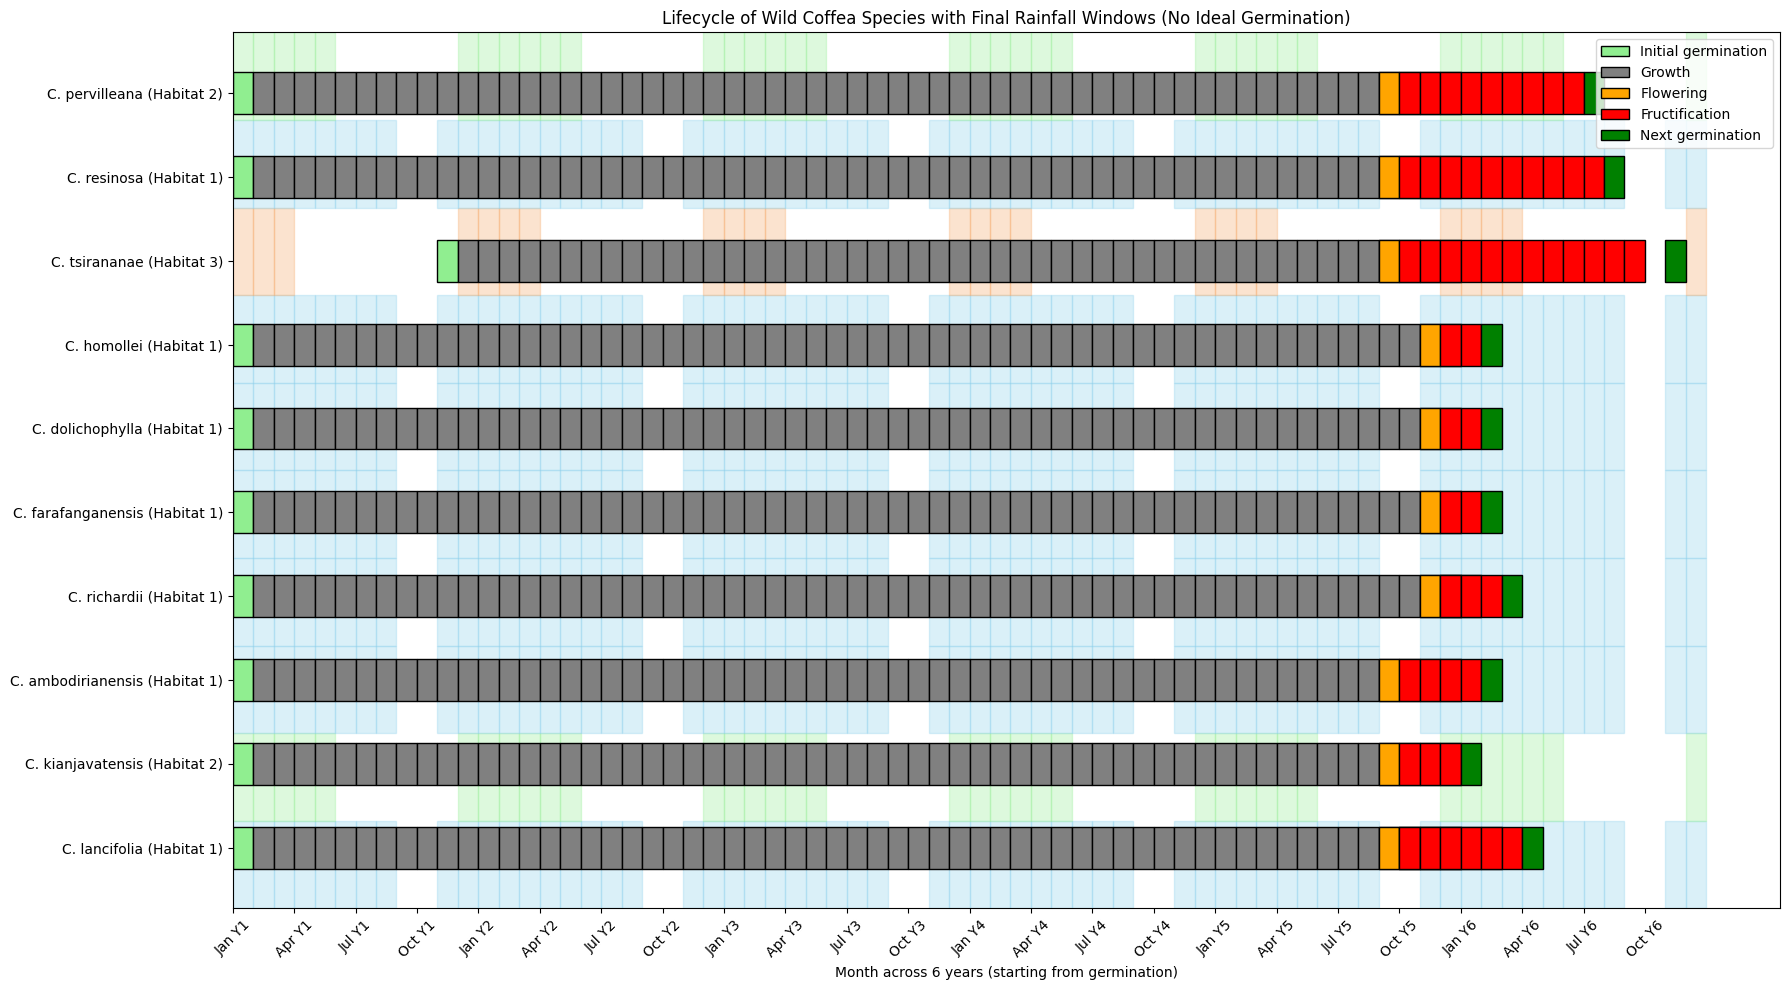

In [41]:
# Corrected rainy months for Habitat 1: Nov to Aug (dry = Sep, Oct)
final_rain_bands = {
    "Habitat 1": [m for m in range(12) if m not in [8, 9]],  # Sep = 8, Oct = 9
    "Habitat 2": [11, 0, 1, 2, 3, 4],  # Dec to Apr
    "Habitat 3": [11, 0, 1, 2]         # Dec to Mar
}
# Replot without ideal germination
fig, ax = plt.subplots(figsize=(18, 10))

for i, (species, vals) in enumerate(phenology_data.items()):
    for y in range(6):
        for m in final_rain_bands[vals["habitat"]]:
            x = m + y * 12
            ax.axvspan(x, x+1, ymin=i/len(phenology_data), ymax=(i+1)/len(phenology_data),
                       color=rain_colors[vals["habitat"]], alpha=0.3)
    for label in ['initial_germination', 'growth', 'flowering', 'fructification', 'next_germination']:
        for m in vals[label]:
            ax.barh(i, 1, left=m, height=0.5, color=colors[label], edgecolor='black')

# Remove 'ideal_germination' from legend
adjusted_legend_elements = [patch for patch in legend_elements if 'Ideal germination' not in patch.get_label()]

# Format chart
ax.set_yticks(range(len(phenology_data)))
ax.set_yticklabels(list(phenology_data.keys()))
ax.set_xticks(range(0, 72, 3))
ax.set_xticklabels([months[i % 12] + f' Y{(i // 12) + 1}' for i in range(0, 72, 3)], rotation=45)
ax.set_xlabel("Month across 6 years (starting from germination)")
ax.set_title("Lifecycle of Wild Coffea Species with Final Rainfall Windows (No Ideal Germination)")
ax.legend(handles=adjusted_legend_elements, loc='upper right')
plt.tight_layout()
plt.show()


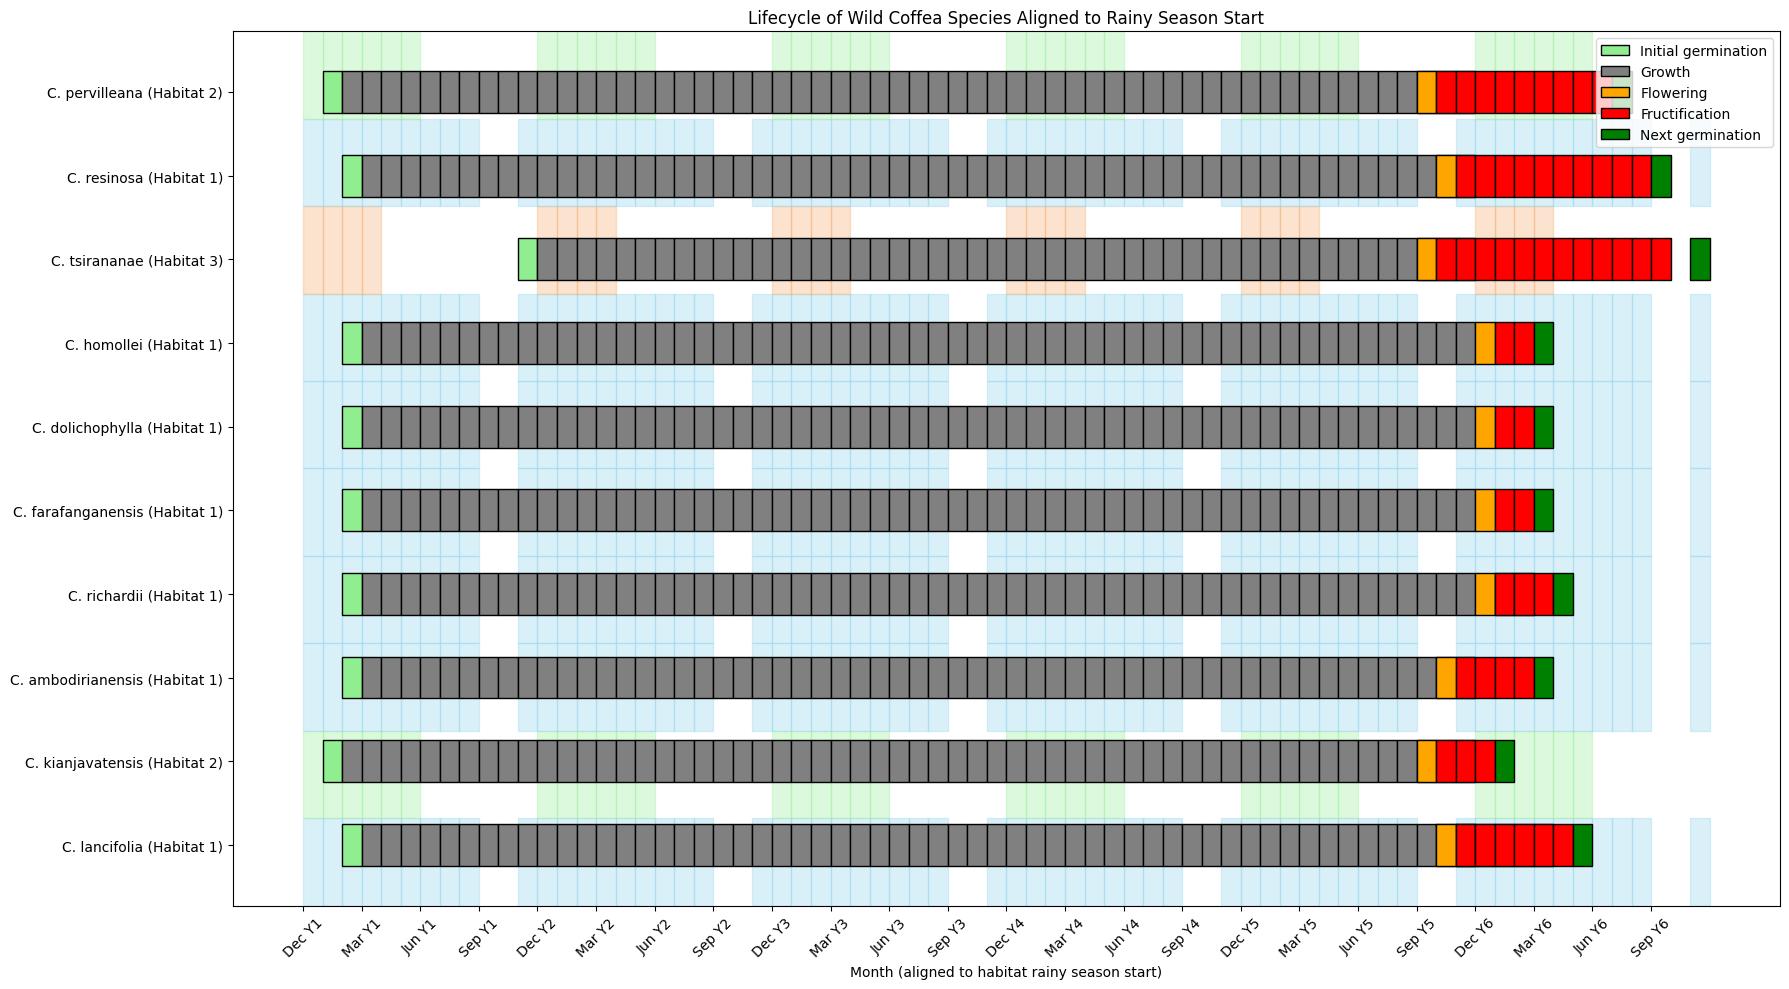

In [42]:
# Recalculate offset start for each habitat: shift timeline so first month is habitat's rainy season start
# Habitat 1: Nov (month 10), Habitat 2: Dec (11), Habitat 3: Dec (11)

# Set offsets per habitat
start_offset_by_habitat = {"Habitat 1": 10, "Habitat 2": 11, "Habitat 3": 11}

# Recreate phenology_data with adjusted starting months
shifted_phenology_data = {}
for sp, vals in all_known_species.items():
    habitat = vals["habitat"]
    offset = start_offset_by_habitat[habitat]
    germ_month = germ_month_by_habitat[habitat]
    base_shift = (12 - offset) % 12

    def shifted(m): return (m + base_shift) % 72

    germ_start = [shifted(month_index(germ_month, 0))]
    flowering = [shifted(m) for m in vals["flowering"]]
    fruiting = [shifted((f + 1 + i) % 72) for f in vals["flowering"] for i in range(vals["fruit_duration"])]
    fruit_end = max(fruiting) + 1
    next_germ = shifted(month_index(germ_month, 5)) if shifted(month_index(germ_month, 5)) >= fruit_end else fruit_end
    growth = list(range(germ_start[0] + 1, 60))

    shifted_phenology_data[f"{sp} ({habitat})"] = {
        "habitat": habitat,
        "initial_germination": germ_start,
        "growth": growth,
        "flowering": flowering,
        "fructification": fruiting,
        "next_germination": [next_germ]
    }

# Replot with shifted timeline
fig, ax = plt.subplots(figsize=(18, 10))

for i, (species, vals) in enumerate(shifted_phenology_data.items()):
    for y in range(6):
        for m in final_rain_bands[vals["habitat"]]:
            shift_m = (m + base_shift) % 12 + y * 12
            ax.axvspan(shift_m, shift_m+1, ymin=i/len(shifted_phenology_data), ymax=(i+1)/len(shifted_phenology_data),
                       color=rain_colors[vals["habitat"]], alpha=0.3)
    for label in ['initial_germination', 'growth', 'flowering', 'fructification', 'next_germination']:
        for m in vals[label]:
            ax.barh(i, 1, left=m, height=0.5, color=colors[label], edgecolor='black')

# Format chart with shifted months
ax.set_yticks(range(len(shifted_phenology_data)))
ax.set_yticklabels(list(shifted_phenology_data.keys()))
ax.set_xticks(range(0, 72, 3))
ax.set_xticklabels([months[(i + offset) % 12] + f' Y{(i // 12) + 1}' for i in range(0, 72, 3)], rotation=45)
ax.set_xlabel("Month (aligned to habitat rainy season start)")
ax.set_title("Lifecycle of Wild Coffea Species Aligned to Rainy Season Start")
ax.legend(handles=adjusted_legend_elements, loc='upper right')
plt.tight_layout()
plt.show()


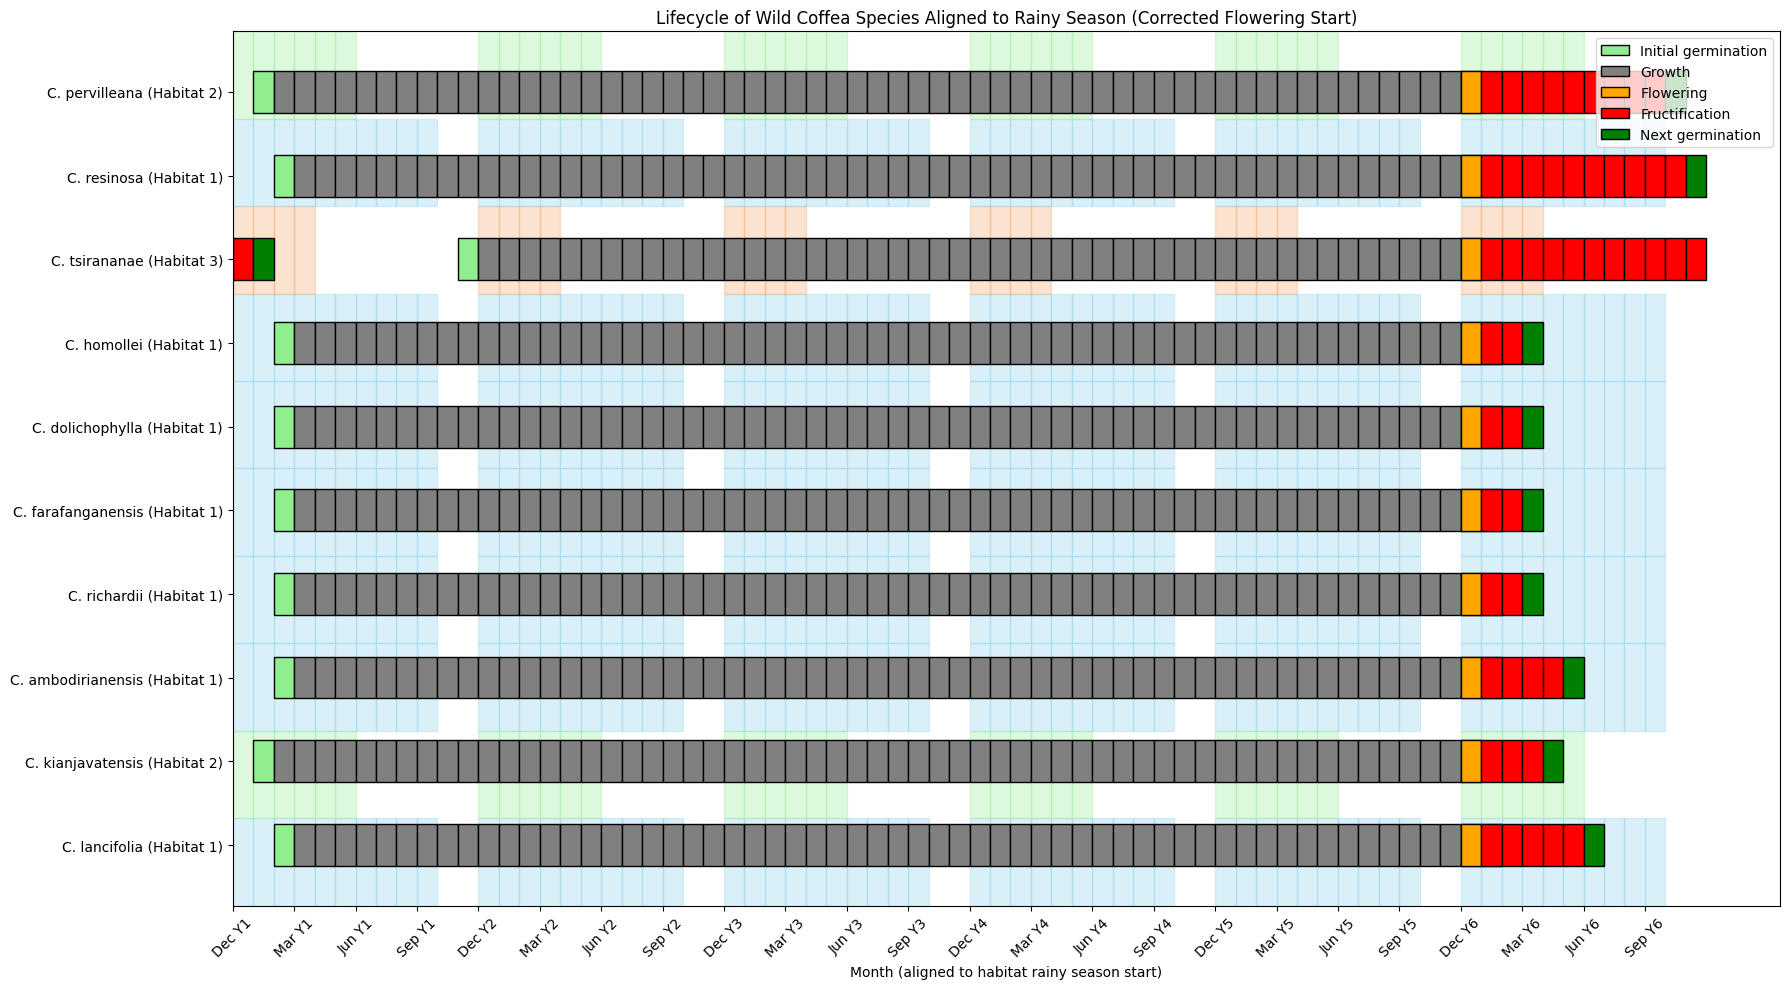

In [43]:
# Rebuild phenology data where flowering always starts at the *beginning of rainy season* (year 4)
flower_start_by_habitat = {"Habitat 1": month_index(10, 4), "Habitat 2": month_index(11, 4), "Habitat 3": month_index(11, 4)}

# Updated phenology with flowering starting at rainy season
corrected_phenology_data = {}
for sp, vals in all_known_species.items():
    habitat = vals["habitat"]
    flower_start = flower_start_by_habitat[habitat]
    flowering = [flower_start]
    fruiting = [((flower_start + 1 + i) % 72) for i in range(vals["fruit_duration"])]
    fruit_end = max(fruiting) + 1
    germ_start = [month_index(germ_month_by_habitat[habitat], 0)]
    growth = list(range(germ_start[0] + 1, 60))
    next_germ = month_index(germ_month_by_habitat[habitat], 5)
    next_germ = next_germ if next_germ >= fruit_end else fruit_end

    corrected_phenology_data[f"{sp} ({habitat})"] = {
        "habitat": habitat,
        "initial_germination": germ_start,
        "growth": growth,
        "flowering": flowering,
        "fructification": fruiting,
        "next_germination": [next_germ]
    }

# Re-plot with corrected flowering phases and shifted timeline
fig, ax = plt.subplots(figsize=(18, 10))

for i, (species, vals) in enumerate(corrected_phenology_data.items()):
    habitat = vals["habitat"]
    offset = start_offset_by_habitat[habitat]
    base_shift = (12 - offset) % 12

    for y in range(6):
        for m in final_rain_bands[habitat]:
            shift_m = (m + base_shift) % 12 + y * 12
            ax.axvspan(shift_m, shift_m+1, ymin=i/len(corrected_phenology_data), ymax=(i+1)/len(corrected_phenology_data),
                       color=rain_colors[habitat], alpha=0.3)

    for label in ['initial_germination', 'growth', 'flowering', 'fructification', 'next_germination']:
        for m in vals[label]:
            shift_m = (m + base_shift) % 72
            ax.barh(i, 1, left=shift_m, height=0.5, color=colors[label], edgecolor='black')

# Final formatting
ax.set_yticks(range(len(corrected_phenology_data)))
ax.set_yticklabels(list(corrected_phenology_data.keys()))
ax.set_xticks(range(0, 72, 3))
ax.set_xticklabels([months[(i + offset) % 12] + f' Y{(i // 12) + 1}' for i in range(0, 72, 3)], rotation=45)
ax.set_xlabel("Month (aligned to habitat rainy season start)")
ax.set_title("Lifecycle of Wild Coffea Species Aligned to Rainy Season (Corrected Flowering Start)")
ax.legend(handles=adjusted_legend_elements, loc='upper right')
plt.tight_layout()
plt.show()


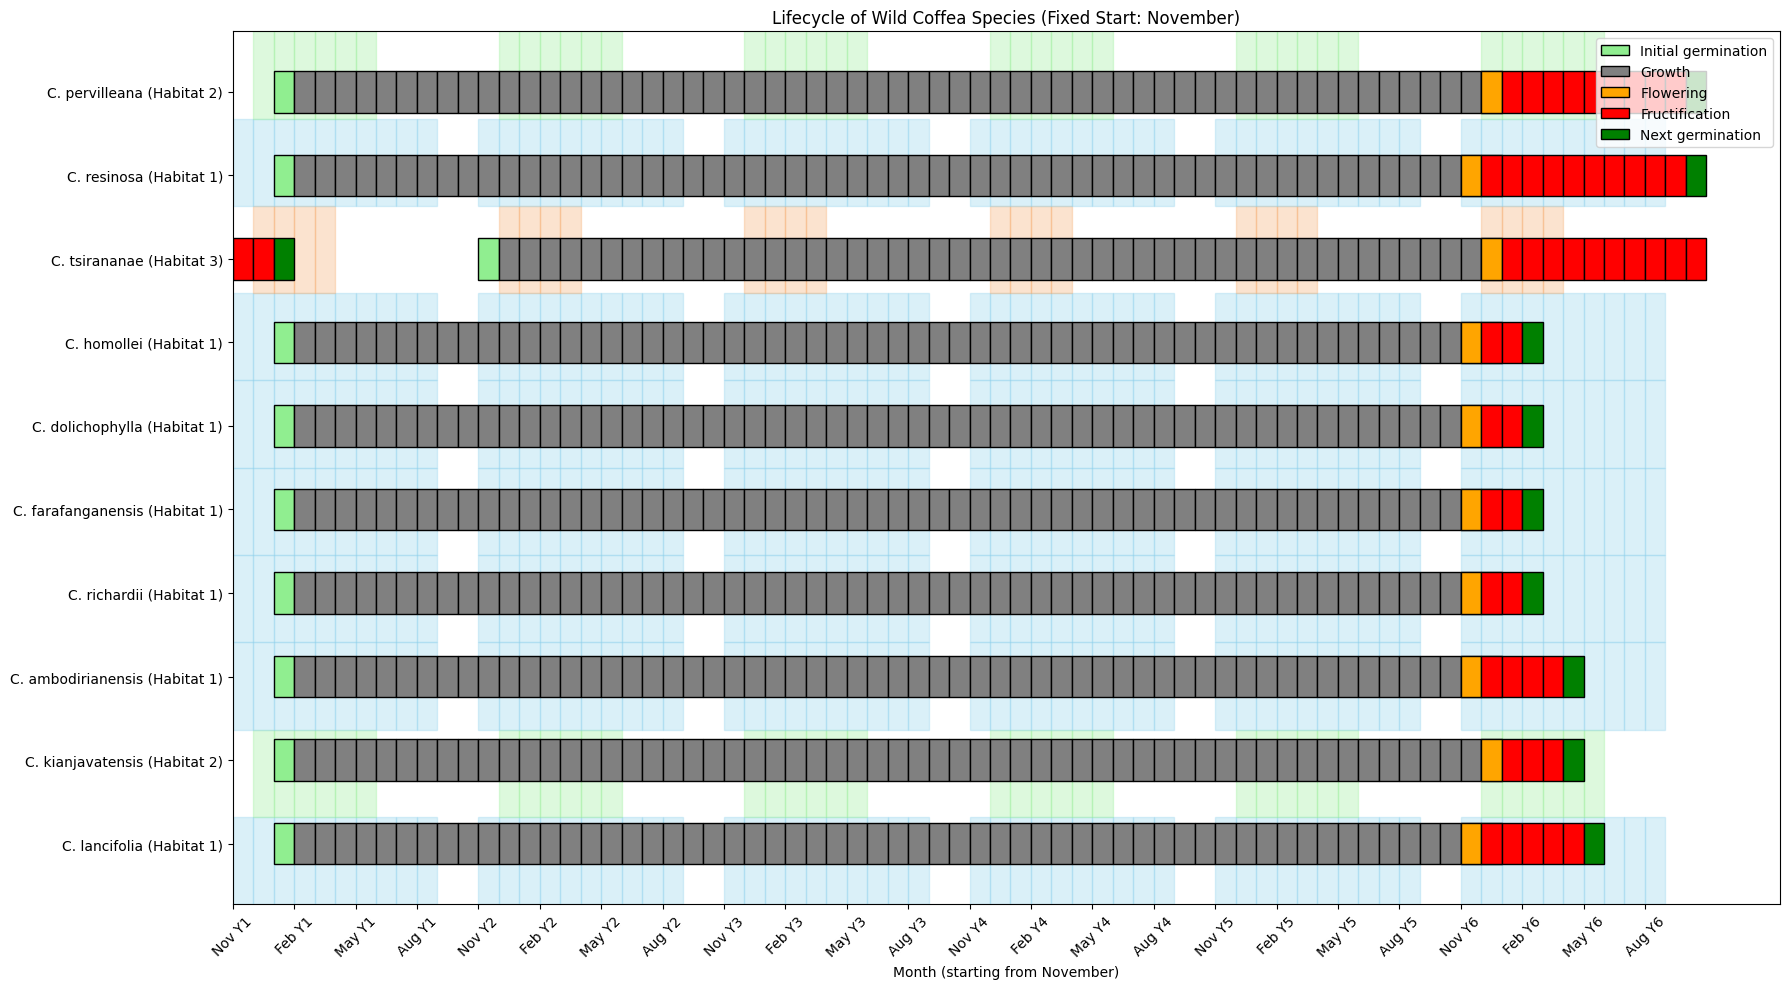

In [46]:
# Now, all x-axes will start from November (month index 10), regardless of habitat
# All phases will retain their original calendar-month timing (unshifted), only the display shifts

# Reconstruct phenology data based on original month calendar (not shifted)
# Then shift display so November is month 0 on x-axis

base_display_shift = (12 - 10) % 12  # shift so Nov (10) becomes x=0

# Keep real biological months
final_phenology_data = {}
for sp, vals in all_known_species.items():
    habitat = vals["habitat"]
    flower_start = flower_start_by_habitat[habitat]
    flowering = [flower_start]
    fruiting = [((flower_start + 1 + i) % 72) for i in range(vals["fruit_duration"])]
    fruit_end = max(fruiting) + 1
    germ_start = [month_index(germ_month_by_habitat[habitat], 0)]
    growth = list(range(germ_start[0] + 1, 60))
    next_germ = month_index(germ_month_by_habitat[habitat], 5)
    next_germ = next_germ if next_germ >= fruit_end else fruit_end

    final_phenology_data[f"{sp} ({habitat})"] = {
        "habitat": habitat,
        "initial_germination": germ_start,
        "growth": growth,
        "flowering": flowering,
        "fructification": fruiting,
        "next_germination": [next_germ]
    }

# Plot all with uniform November start
fig, ax = plt.subplots(figsize=(18, 10))

for i, (species, vals) in enumerate(final_phenology_data.items()):
    habitat = vals["habitat"]
    for y in range(6):
        for m in final_rain_bands[habitat]:
            shift_m = (m + base_display_shift) % 12 + y * 12
            ax.axvspan(shift_m, shift_m+1, ymin=i/len(final_phenology_data), ymax=(i+1)/len(final_phenology_data),
                       color=rain_colors[habitat], alpha=0.3)

    for label in ['initial_germination', 'growth', 'flowering', 'fructification', 'next_germination']:
        for m in vals[label]:
            shift_m = (m + base_display_shift) % 72
            ax.barh(i, 1, left=shift_m, height=0.5, color=colors[label], edgecolor='black')

# Final formatting with universal Nov start
ax.set_yticks(range(len(final_phenology_data)))
ax.set_yticklabels(list(final_phenology_data.keys()))
ax.set_xticks(range(0, 72, 3))
ax.set_xticklabels([months[(i + 10) % 12] + f' Y{(i // 12) + 1}' for i in range(0, 72, 3)], rotation=45)
ax.set_xlabel("Month (starting from November)")
ax.set_title("Lifecycle of Wild Coffea Species (Fixed Start: November)")
ax.legend(handles=adjusted_legend_elements, loc='upper right')
plt.tight_layout()
plt.show()


In [48]:

final_adjusted_data = {}
for sp, vals in all_known_species.items():
    habitat = vals["habitat"]
    flower_start = flower_start_by_habitat[habitat]

    # Adjust flowering and next germination placement to appear later if needed
    if "tsirananae" in sp:
        flower_start += 24  # move flowering later in timeline
    flowering = [flower_start]
    fruiting = [((flower_start + 1 + i) % 72) for i in range(vals["fruit_duration"])]
    fruit_end = max(fruiting) + 1

    germ_start = [month_index(germ_month_by_habitat[habitat], 0)]
    growth = list(range(germ_start[0] + 1, 60))

    # Next germ adjusted: if still before fruit end, push one year ahead
    next_germ = month_index(germ_month_by_habitat[habitat], 5)
    if next_germ <= fruit_end:
        next_germ = fruit_end + 12

    final_adjusted_data[f"{sp} ({habitat})"] = {
        "habitat": habitat,
        "initial_germination": germ_start,
        "growth": growth,
        "flowering": flowering,
        "fructification": fruiting,
        "next_germination": [next_germ]
    }

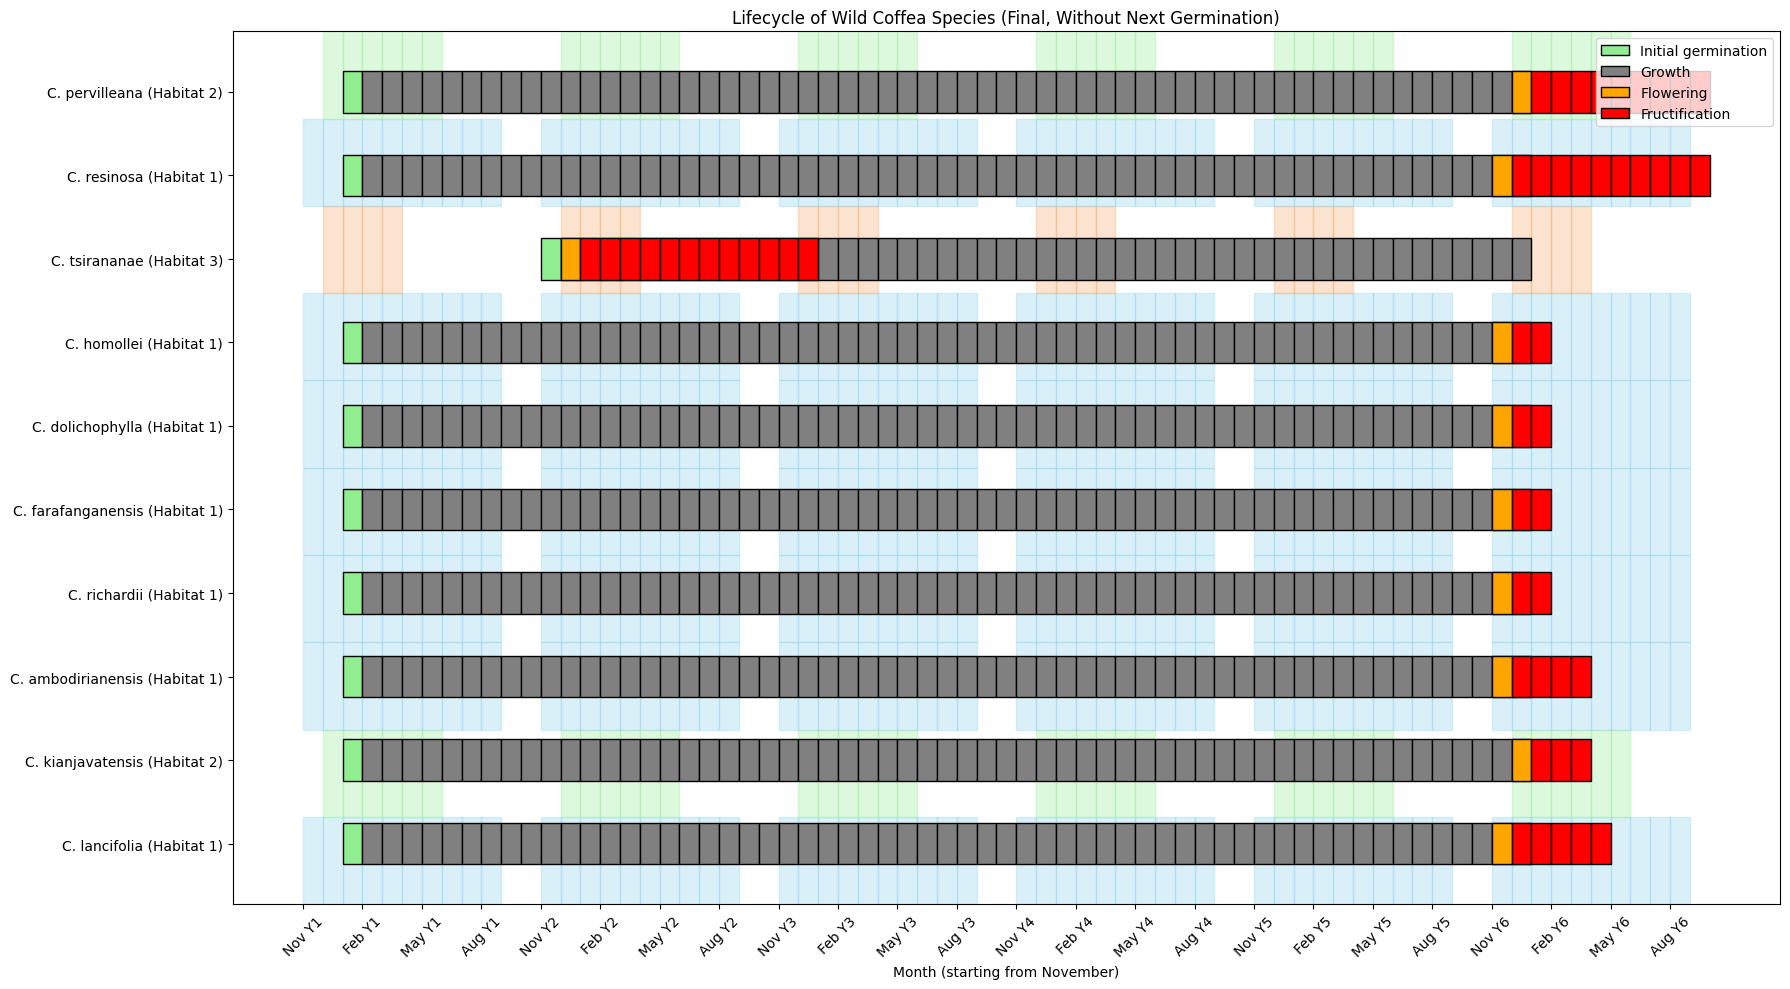

In [49]:
# Replot without 'next_germination'
fig, ax = plt.subplots(figsize=(18, 10))

for i, (species, vals) in enumerate(final_adjusted_data.items()):
    habitat = vals["habitat"]
    for y in range(6):
        for m in final_rain_bands[habitat]:
            shift_m = (m + base_display_shift) % 12 + y * 12
            ax.axvspan(shift_m, shift_m+1, ymin=i/len(final_adjusted_data), ymax=(i+1)/len(final_adjusted_data),
                       color=rain_colors[habitat], alpha=0.3)

    for label in ['initial_germination', 'growth', 'flowering', 'fructification']:  # omit next_germination
        for m in vals[label]:
            shift_m = (m + base_display_shift) % 72
            ax.barh(i, 1, left=shift_m, height=0.5, color=colors[label], edgecolor='black')

# Update legend to remove next germination
final_legend_elements = [patch for patch in adjusted_legend_elements if 'Next germination' not in patch.get_label()]

# Final formatting
ax.set_yticks(range(len(final_adjusted_data)))
ax.set_yticklabels(list(final_adjusted_data.keys()))
ax.set_xticks(range(0, 72, 3))
ax.set_xticklabels([months[(i + 10) % 12] + f' Y{(i // 12) + 1}' for i in range(0, 72, 3)], rotation=45)
ax.set_xlabel("Month (starting from November)")
ax.set_title("Lifecycle of Wild Coffea Species (Final, Without Next Germination)")
ax.legend(handles=final_legend_elements, loc='upper right')
plt.tight_layout()
plt.show()


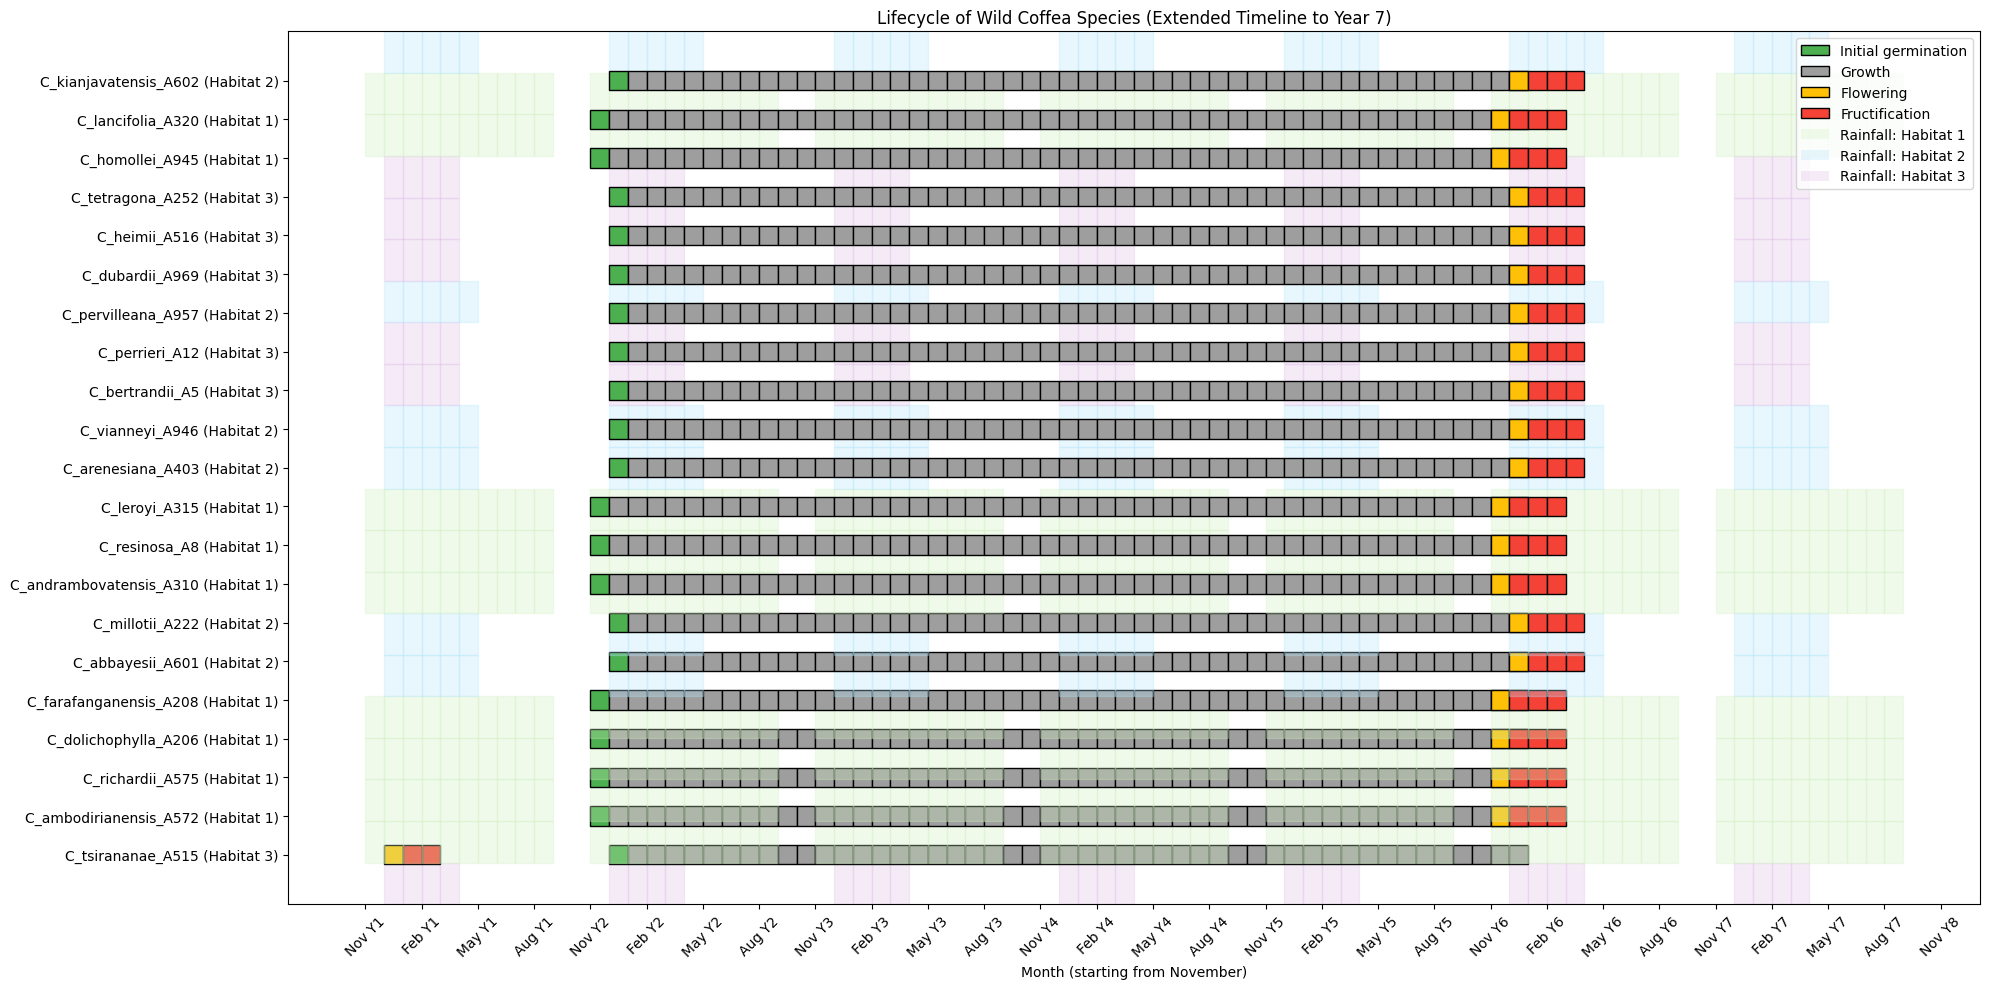

In [51]:
# Since the execution environment reset, we need to fully regenerate the `final_adjusted_data` dictionary

# Helper functions
def month_index(month, year): return year * 12 + month

# Month offsets and rainfall bands
germ_month_by_habitat = {"Habitat 1": "Nov", "Habitat 2": "Dec", "Habitat 3": "Dec"}
month_names = {name: i for i, name in enumerate(months)}
fruit_duration_by_species = {
    'C_tsirananae_A515': 2, 'C_ambodirianensis_A572': 3, 'C_richardii_A575': 3, 'C_dolichophylla_A206': 3,
    'C_farafanganensis_A208': 3, 'C_abbayesii_A601': 3, 'C_millotii_A222': 3, 'C_andrambovatensis_A310': 3,
    'C_resinosa_A8': 3, 'C_leroyi_A315': 3, 'C_arenesiana_A403': 3, 'C_vianneyi_A946': 3, 'C_bertrandii_A5': 3,
    'C_perrieri_A12': 3, 'C_pervilleana_A957': 3, 'C_dubardii_A969': 3, 'C_heimii_A516': 3, 'C_tetragona_A252': 3,
    'C_homollei_A945': 3, 'C_lancifolia_A320': 3, 'C_kianjavatensis_A602': 3
}
flower_start_by_habitat = {"Habitat 1": month_index(10, 4), "Habitat 2": month_index(11, 4), "Habitat 3": month_index(11, 4)}

# Minimal species-habitat mapping to rebuild final_adjusted_data
species_habitat_map = {
    'C_tsirananae_A515': 'Habitat 3', 'C_ambodirianensis_A572': 'Habitat 1', 'C_richardii_A575': 'Habitat 1',
    'C_dolichophylla_A206': 'Habitat 1', 'C_farafanganensis_A208': 'Habitat 1', 'C_abbayesii_A601': 'Habitat 2',
    'C_millotii_A222': 'Habitat 2', 'C_andrambovatensis_A310': 'Habitat 1', 'C_resinosa_A8': 'Habitat 1',
    'C_leroyi_A315': 'Habitat 1', 'C_arenesiana_A403': 'Habitat 2', 'C_vianneyi_A946': 'Habitat 2',
    'C_bertrandii_A5': 'Habitat 3', 'C_perrieri_A12': 'Habitat 3', 'C_pervilleana_A957': 'Habitat 2',
    'C_dubardii_A969': 'Habitat 3', 'C_heimii_A516': 'Habitat 3', 'C_tetragona_A252': 'Habitat 3',
    'C_homollei_A945': 'Habitat 1', 'C_lancifolia_A320': 'Habitat 1', 'C_kianjavatensis_A602': 'Habitat 2'
}

# Regenerate final_adjusted_data
final_adjusted_data = {}
for sp, habitat in species_habitat_map.items():
    flower_start = flower_start_by_habitat[habitat]
    if "tsirananae" in sp:
        flower_start += 24  # push flowering to later years
    flowering = [flower_start]
    fruit_duration = fruit_duration_by_species.get(sp, 3)
    fruiting = [((flower_start + 1 + i) % 84) for i in range(fruit_duration)]
    fruit_end = max(fruiting) + 1

    germ_month = month_names[germ_month_by_habitat[habitat]]
    germ_start = [month_index(germ_month, 0)]
    growth = list(range(germ_start[0] + 1, 60))

    final_adjusted_data[f"{sp} ({habitat})"] = {
        "habitat": habitat,
        "initial_germination": germ_start,
        "growth": growth,
        "flowering": flowering,
        "fructification": fruiting
    }

# Replot with corrected dataset and extended range
fig, ax = plt.subplots(figsize=(20, 10))

for i, (species, vals) in enumerate(final_adjusted_data.items()):
    habitat = vals["habitat"]
    for y in range(7):
        for m in final_rain_bands[habitat]:
            shift_m = (m + base_display_shift) % 12 + y * 12
            ax.axvspan(shift_m, shift_m+1, ymin=i/len(final_adjusted_data), ymax=(i+1)/len(final_adjusted_data),
                       color=rain_colors[habitat], alpha=0.3)

    for label in ['initial_germination', 'growth', 'flowering', 'fructification']:
        for m in vals[label]:
            shift_m = (m + base_display_shift) % 84
            ax.barh(i, 1, left=shift_m, height=0.5, color=colors[label], edgecolor='black')

# Format axis
ax.set_yticks(range(len(final_adjusted_data)))
ax.set_yticklabels(list(final_adjusted_data.keys()))
ax.set_xticks(range(0, 85, 3))
ax.set_xticklabels([months[(i + 10) % 12] + f' Y{(i // 12) + 1}' for i in range(0, 85, 3)], rotation=45)
ax.set_xlabel("Month (starting from November)")
ax.set_title("Lifecycle of Wild Coffea Species (Extended Timeline to Year 7)")
ax.legend(handles=final_legend_elements, loc='upper right')
plt.tight_layout()
plt.show()


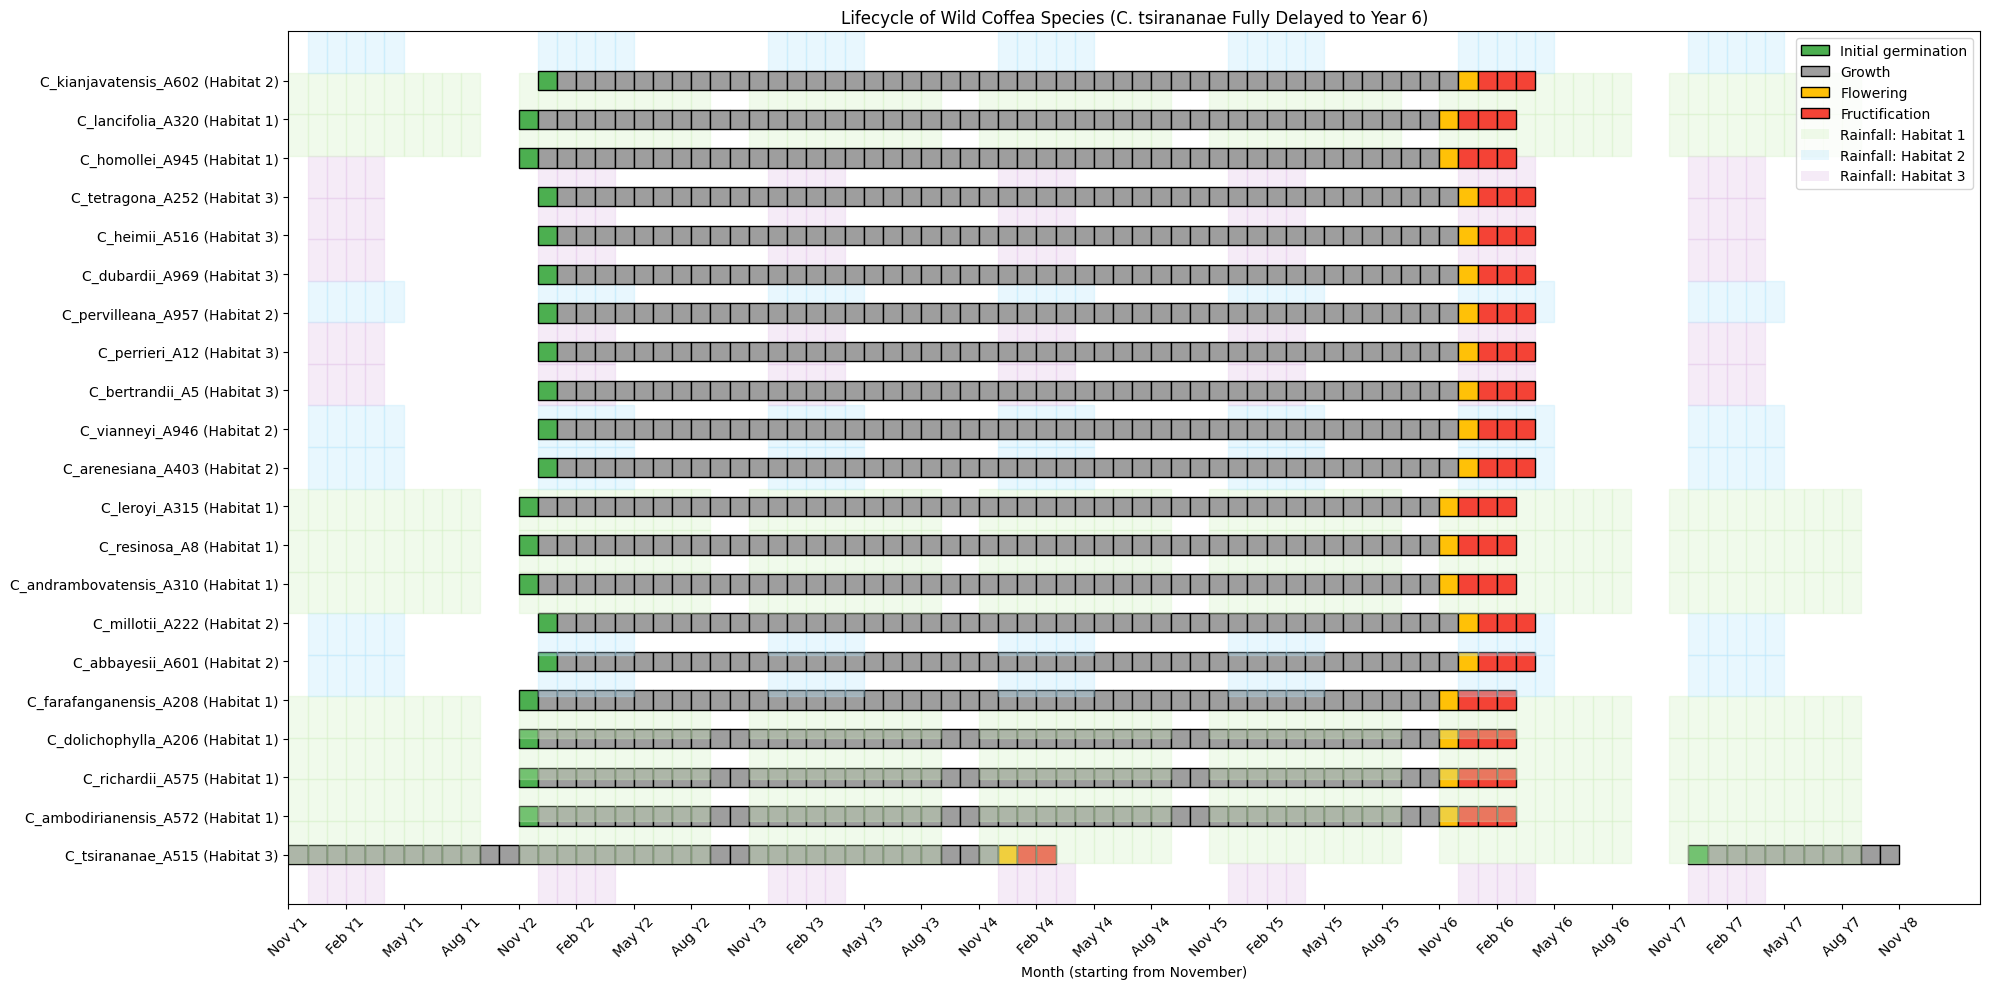

In [52]:
# Ensure C_tsirananae_A515's events are ALL pushed into later years (e.g., Year 6 or 7)
# Adjust all phenology phases (flowering, fruiting, growth) accordingly

adjusted_final_data_tsirananae_fixed = {}
for sp, habitat in species_habitat_map.items():
    flower_start = flower_start_by_habitat[habitat]

    # Apply a late shift for C_tsirananae_A515 to push all phenology phases to Year 6+
    shift_years = 0
    if "tsirananae" in sp:
        shift_years = 5
        flower_start += shift_years * 12

    flowering = [flower_start]
    fruit_duration = fruit_duration_by_species.get(sp, 3)
    fruiting = [flower_start + 1 + i for i in range(fruit_duration)]
    fruit_end = max(fruiting) + 1

    germ_month = month_names[germ_month_by_habitat[habitat]]
    germ_start = [month_index(germ_month, 0) + (shift_years * 12 if "tsirananae" in sp else 0)]
    growth = list(range(germ_start[0] + 1, flower_start))  # Growth ends at flowering

    adjusted_final_data_tsirananae_fixed[f"{sp} ({habitat})"] = {
        "habitat": habitat,
        "initial_germination": germ_start,
        "growth": growth,
        "flowering": flowering,
        "fructification": fruiting
    }

# Plot again
fig, ax = plt.subplots(figsize=(20, 10))

for i, (species, vals) in enumerate(adjusted_final_data_tsirananae_fixed.items()):
    habitat = vals["habitat"]
    for y in range(7):
        for m in final_rain_bands[habitat]:
            shift_m = (m + base_display_shift) % 12 + y * 12
            ax.axvspan(shift_m, shift_m+1, ymin=i/len(adjusted_final_data_tsirananae_fixed), ymax=(i+1)/len(adjusted_final_data_tsirananae_fixed),
                       color=rain_colors[habitat], alpha=0.3)

    for label in ['initial_germination', 'growth', 'flowering', 'fructification']:
        for m in vals[label]:
            shift_m = (m + base_display_shift) % 84
            ax.barh(i, 1, left=shift_m, height=0.5, color=colors[label], edgecolor='black')

# Format
ax.set_yticks(range(len(adjusted_final_data_tsirananae_fixed)))
ax.set_yticklabels(list(adjusted_final_data_tsirananae_fixed.keys()))
ax.set_xticks(range(0, 85, 3))
ax.set_xticklabels([months[(i + 10) % 12] + f' Y{(i // 12) + 1}' for i in range(0, 85, 3)], rotation=45)
ax.set_xlabel("Month (starting from November)")
ax.set_title("Lifecycle of Wild Coffea Species (C. tsirananae Fully Delayed to Year 6)")
ax.legend(handles=final_legend_elements, loc='upper right')
plt.tight_layout()
plt.show()


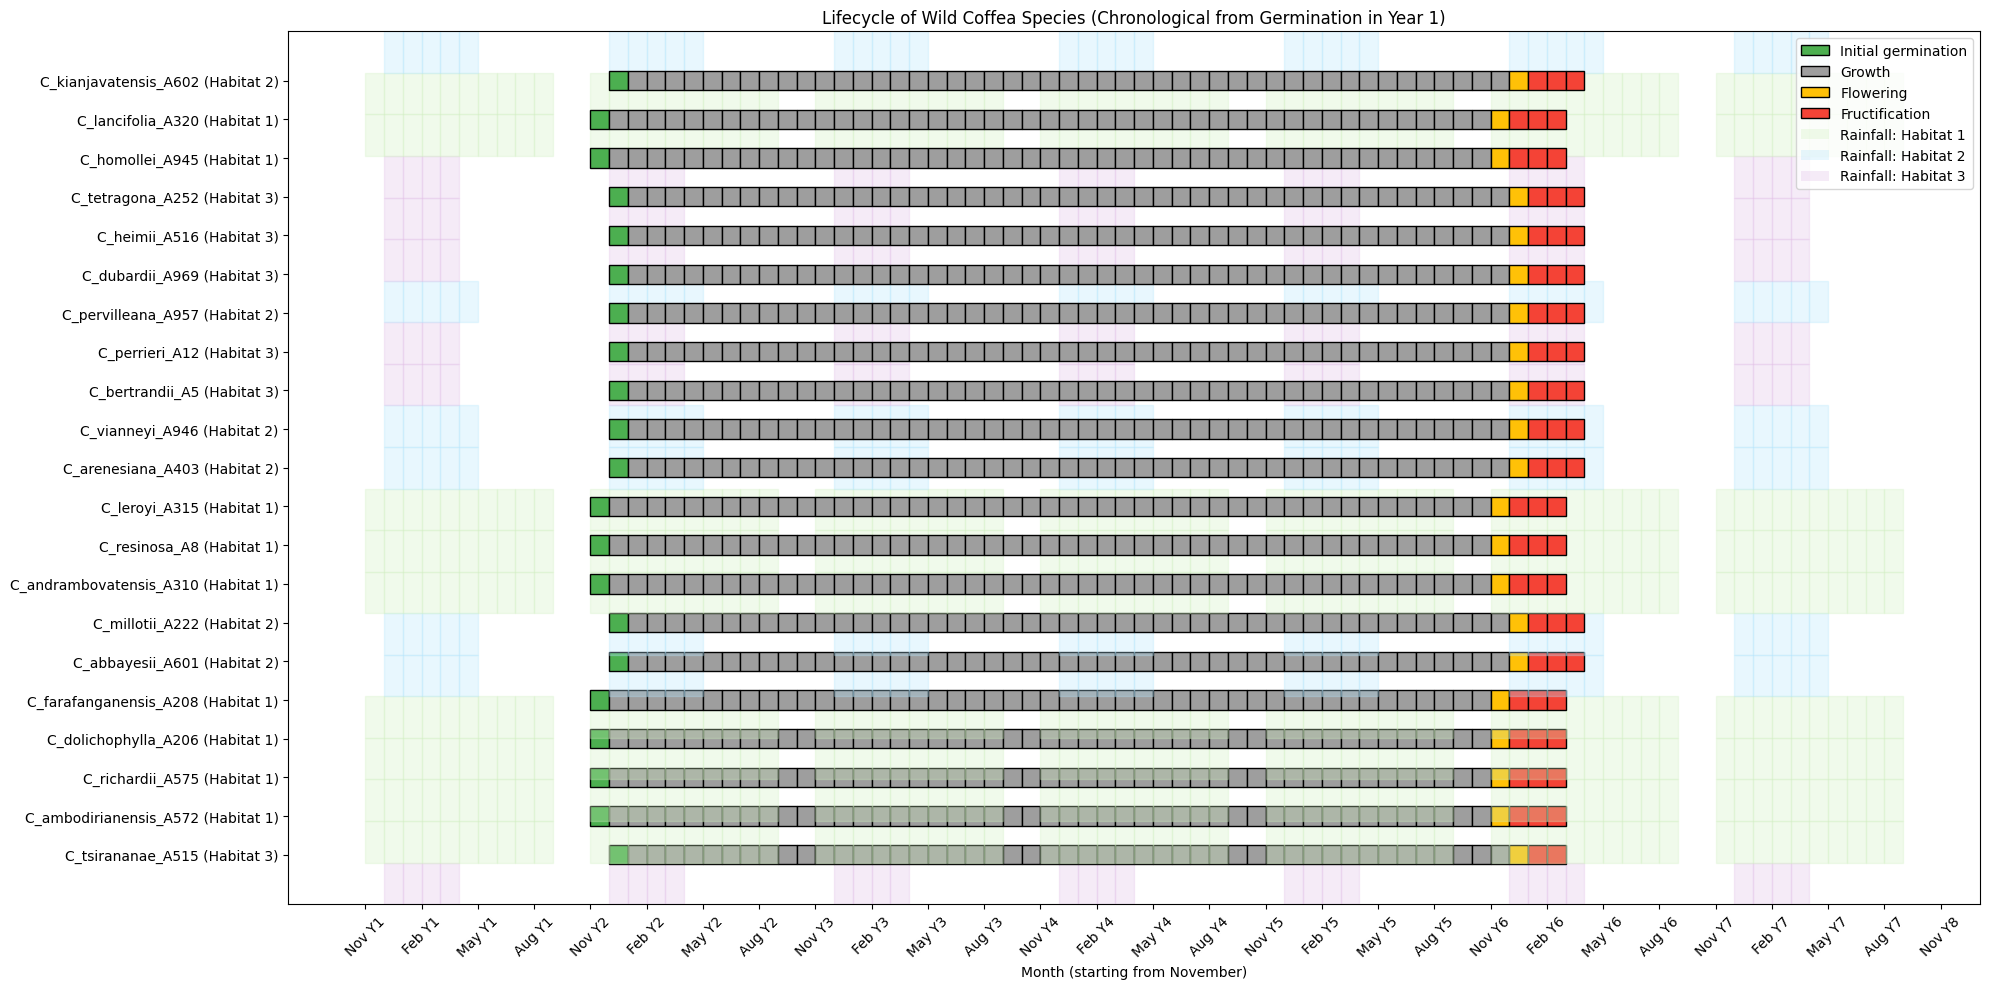

In [53]:
# Adjust all germination phases to start in Year 1 (i.e., months 0–11)
# Growth will proceed until flowering
# Flowering/fructification remain unchanged (but appear later in timeline)

final_data_germination_chronological = {}
for sp, habitat in species_habitat_map.items():
    flower_start = flower_start_by_habitat[habitat]
    fruit_duration = fruit_duration_by_species.get(sp, 3)

    # Set germination at year 1 for all
    germ_month = month_names[germ_month_by_habitat[habitat]]
    germ_start = [month_index(germ_month, 0)]  # always in year 1

    growth = list(range(germ_start[0] + 1, flower_start))  # until flowering
    flowering = [flower_start]
    fruiting = [flower_start + 1 + i for i in range(fruit_duration)]

    final_data_germination_chronological[f"{sp} ({habitat})"] = {
        "habitat": habitat,
        "initial_germination": germ_start,
        "growth": growth,
        "flowering": flowering,
        "fructification": fruiting
    }

# Plot the updated version
fig, ax = plt.subplots(figsize=(20, 10))

for i, (species, vals) in enumerate(final_data_germination_chronological.items()):
    habitat = vals["habitat"]
    for y in range(7):
        for m in final_rain_bands[habitat]:
            shift_m = (m + base_display_shift) % 12 + y * 12
            ax.axvspan(shift_m, shift_m+1, ymin=i/len(final_data_germination_chronological), ymax=(i+1)/len(final_data_germination_chronological),
                       color=rain_colors[habitat], alpha=0.3)

    for label in ['initial_germination', 'growth', 'flowering', 'fructification']:
        for m in vals[label]:
            shift_m = (m + base_display_shift) % 84
            ax.barh(i, 1, left=shift_m, height=0.5, color=colors[label], edgecolor='black')

# Final formatting
ax.set_yticks(range(len(final_data_germination_chronological)))
ax.set_yticklabels(list(final_data_germination_chronological.keys()))
ax.set_xticks(range(0, 85, 3))
ax.set_xticklabels([months[(i + 10) % 12] + f' Y{(i // 12) + 1}' for i in range(0, 85, 3)], rotation=45)
ax.set_xlabel("Month (starting from November)")
ax.set_title("Lifecycle of Wild Coffea Species (Chronological from Germination in Year 1)")
ax.legend(handles=final_legend_elements, loc='upper right')
plt.tight_layout()
plt.show()
